In [1]:
from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))

### ¿Geopandas?

Geopandas enables the use and manipulation of geospatial data in Python. It extends the common datatype used in pandas to allow for the many and unique geometric operations: GeoSeries and GeoDataFrame. Geopandas is also built on top of shapely for its geometric operation; its underlying datatype allows Geopandas to run blazingly fast and is appropriate for many machine learning pipelines that require large geospatial datasets.

### Instalation 

Following steps:

#### 1. create new environment

conda creare -name new_env

#### 2. Activate new environment
conda activate new_env

#### 3. Install package 

conda install -c conda-forge python=3 geopandas

### Geopandas data types

Shapefile (.shp): vector data that stores geospatial information such as topology, shape geometry, coordinate etc

GeoJSON (.geojson): geospatial information and relevant characteristics (object or string)

Finally, Geopandas creates an additional geometry column


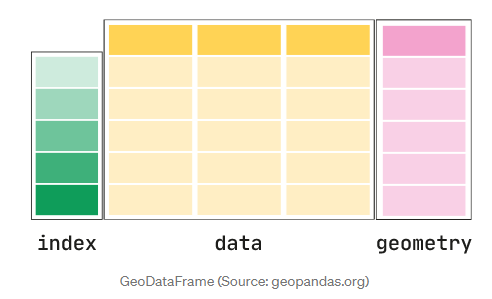


### Coordinate Reference Systems (crs)

The coordinate reference systems tell us how GeodataFrame o GeoSeries relate to places on Earth

#### relevant operations: setting a projection and re-projecting 

setting projection: geopandas.read_file() most of time includes projection information. Check using "Geoseries.crs"
If GeoDataframe does not include projection, hence use data["geometry"].set_crs(epsg=4326) for WGS-84.

### WGS-84: 
The Global Positioning System uses the World Geodetic System (WGS84) as its reference coordinate system. It's made up of a reference ellipsoid, a standard coordinate system, altitude data, and a geoid

### Reprojecting:

In somes cases, due to distortions in bidimensional plane and your application of geospatial data, re-projection is required. 

A commonly used default is Universal Transverse Mercator (UTM)







In [2]:
# Dependencias ya instaladas en el entorno .venv de esta carpeta.
# Si necesitas reinstalar, usa el magic (instala en ESTE kernel, no en el Python del sistema):
# %pip install chardet

In [3]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np
import matplotlib.pyplot as plt 
import chardet

In [4]:
import geopandas as gpd
from geopandas import GeoSeries
from shapely.geometry import Point, LineString
import folium 
from folium import Marker, GeoJson
from folium.plugins import MarkerCluster, HeatMap

In [5]:
# !pip install folium

In [6]:
# Gettting the character format (encoding type)

base = open(r'../../_data/Datos_panel_distritos.csv', 'rb').read()
det = chardet.detect(base)
charenc = det['encoding']
charenc 

'utf-8'

## Covid Data

In [7]:
# Import csv file from panel covid information at distric level
# Panel data from march-2020 to first two wees of january-2022

cv_data = pd.read_csv( r'../../_data/Datos_panel_distritos.csv', encoding = charenc)
cv_data.head( 5 )

,Código,Departamento,Provincia,Distrito,Mes,Año,Casos,Muertes Covid,Muertes totales
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,3,2020,0,0,16
1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,4,2020,47,0,5
2,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,5,2020,165,3,11
3,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,6,2020,119,2,15
4,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,7,2020,175,2,8


In [8]:
cv_data.dtypes

Código             int64
Departamento         str
Provincia            str
Distrito             str
Mes                int64
Año                int64
Casos              int64
Muertes Covid      int64
Muertes totales    int64
dtype: object

In [9]:
# rename variable to merge later 
cv_data = cv_data.rename({'Código':'UBIGEO'}, axis =1 )
cv_data.head( 5 )

,UBIGEO,Departamento,Provincia,Distrito,Mes,Año,Casos,Muertes Covid,Muertes totales
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,3,2020,0,0,16
1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,4,2020,47,0,5
2,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,5,2020,165,3,11
3,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,6,2020,119,2,15
4,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,7,2020,175,2,8


## Shape File

In [10]:
# Upload shape file at district level

maps = gpd.read_file(r'../../_data/Folium/DISTRITOS.shp')

In [11]:
maps

,IDDPTO,DEPARTAMEN,IDPROV,PROVINCIA,IDDIST,DISTRITO,CAPITAL,CODCCPP,AREA,FUENTE,geometry
0,10,HUANUCO,1009,PUERTO INCA,100902,CODO DEL POZUZO,CODO DEL POZUZO,0001,1,INEI,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975..."
1,10,HUANUCO,1009,PUERTO INCA,100904,TOURNAVISTA,TOURNAVISTA,0001,1,INEI,"POLYGON ((-74.64136 -8.82302, -74.64036 -8.828..."
2,25,UCAYALI,2503,PADRE ABAD,250305,ALEXANDER VON HUMBOLDT,ALEXANDER VON HUMBOLDT,0001,1,INEI,"POLYGON ((-75.02253 -8.74193, -75.02267 -8.742..."
3,25,UCAYALI,2503,PADRE ABAD,250302,IRAZOLA,SAN ALEJANDRO,0001,1,INEI,"POLYGON ((-75.13864 -8.56712, -75.13956 -8.569..."
4,25,UCAYALI,2503,PADRE ABAD,250304,NESHUYA,MONTE ALEGRE,0001,1,INEI,"POLYGON ((-75.01589 -8.44637, -75.01585 -8.446..."
...,...,...,...,...,...,...,...,...,...,...,...
1868,10,HUANUCO,1006,LEONCIO PRADO,100608,CASTILLO GRANDE,CASTILLO GRANDE,0001,1,INEI,"POLYGON ((-76.08083 -9.13017, -76.08026 -9.130..."
1869,10,HUANUCO,1006,LEONCIO PRADO,100609,PUEBLO NUEVO,PUEBLO NUEVO,0001,1,INEI,"POLYGON ((-75.88828 -9.00906, -75.88756 -9.010..."
1870,10,HUANUCO,1006,LEONCIO PRADO,100610,SANTO DOMINGO DE ANDA,PACAE,0001,1,INEI,"POLYGON ((-75.91141 -8.88593, -75.91182 -8.886..."
1871,21,PUNO,2111,SAN ROMAN,211105,SAN MIGUEL,SAN MIGUEL,0001,1,INEI,"POLYGON ((-70.13203 -15.33382, -70.12355 -15.3..."


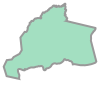

In [12]:
# Plot 1 district (its a collection of points)
maps['geometry'].iloc[2]

In [13]:
## Set of points for first district
maps.geometry[0].boundary.coords.xy

(array('d', [-75.31797010604475, -75.31710488392423, -75.31604648791898, -75.31537303628215, -75.31469932241646, -75.31392881111611, -75.3133303495971, -75.31169723519622, -75.30615235974136, -75.30464848475174, -75.30204673484673, -75.30106448524998, -75.29776760924966, -75.29447260989667, -75.28983985902022, -75.28862698442924, -75.2863086102684, -75.2851563586247, -75.28393560955703, -75.28272260912615, -75.28220311024171, -75.28202736045313, -75.28138673398348, -75.28156248370055, -75.28098236019497, -75.28017386006405, -75.27959373487306, -75.27774798404425, -75.27780860999633, -75.27711523520276, -75.27648235912312, -75.27555073511627, -75.27393360884412, -75.27306448398218, -75.27278123480181, -75.27197261018847, -75.27063673497003, -75.26936310921559, -75.26861523478374, -75.26768548488297, -75.26531248414989, -75.26329098403181, -75.26230660998112, -75.26178710908653, -75.26045898389629, -75.2592461099199, -75.25808785916968, -75.25611910895401, -75.25409760880586, -75.2502148

In [14]:
type(maps.geometry)

geopandas.geoseries.GeoSeries

In [15]:
#Check unique values

maps['IDDIST'].is_unique

True

In [16]:
maps['IDDIST'].unique().size

1873

In [17]:
# Select only relevant columns
maps = maps[['IDDIST', 'geometry']]
maps = maps.rename({'IDDIST':'UBIGEO'}, axis =1 )
maps

,UBIGEO,geometry
0,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975..."
1,100904,"POLYGON ((-74.64136 -8.82302, -74.64036 -8.828..."
2,250305,"POLYGON ((-75.02253 -8.74193, -75.02267 -8.742..."
3,250302,"POLYGON ((-75.13864 -8.56712, -75.13956 -8.569..."
4,250304,"POLYGON ((-75.01589 -8.44637, -75.01585 -8.446..."
...,...,...
1868,100608,"POLYGON ((-76.08083 -9.13017, -76.08026 -9.130..."
1869,100609,"POLYGON ((-75.88828 -9.00906, -75.88756 -9.010..."
1870,100610,"POLYGON ((-75.91141 -8.88593, -75.91182 -8.886..."
1871,211105,"POLYGON ((-70.13203 -15.33382, -70.12355 -15.3..."


In [18]:
maps.dtypes

UBIGEO           str
geometry    geometry
dtype: object

In [19]:
# Object or srting to int

maps['UBIGEO'] = maps['UBIGEO'].astype(str).astype(int)
maps

,UBIGEO,geometry
0,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975..."
1,100904,"POLYGON ((-74.64136 -8.82302, -74.64036 -8.828..."
2,250305,"POLYGON ((-75.02253 -8.74193, -75.02267 -8.742..."
3,250302,"POLYGON ((-75.13864 -8.56712, -75.13956 -8.569..."
4,250304,"POLYGON ((-75.01589 -8.44637, -75.01585 -8.446..."
...,...,...
1868,100608,"POLYGON ((-76.08083 -9.13017, -76.08026 -9.130..."
1869,100609,"POLYGON ((-75.88828 -9.00906, -75.88756 -9.010..."
1870,100610,"POLYGON ((-75.91141 -8.88593, -75.91182 -8.886..."
1871,211105,"POLYGON ((-70.13203 -15.33382, -70.12355 -15.3..."


In [20]:
maps

,UBIGEO,geometry
0,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975..."
1,100904,"POLYGON ((-74.64136 -8.82302, -74.64036 -8.828..."
2,250305,"POLYGON ((-75.02253 -8.74193, -75.02267 -8.742..."
3,250302,"POLYGON ((-75.13864 -8.56712, -75.13956 -8.569..."
4,250304,"POLYGON ((-75.01589 -8.44637, -75.01585 -8.446..."
...,...,...
1868,100608,"POLYGON ((-76.08083 -9.13017, -76.08026 -9.130..."
1869,100609,"POLYGON ((-75.88828 -9.00906, -75.88756 -9.010..."
1870,100610,"POLYGON ((-75.91141 -8.88593, -75.91182 -8.886..."
1871,211105,"POLYGON ((-70.13203 -15.33382, -70.12355 -15.3..."


In [21]:
# Ensure the dataset is in WGS-84 (EPSG:4326)
maps = maps.to_crs(epsg=4326)
maps.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [22]:
maps

,UBIGEO,geometry
0,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975..."
1,100904,"POLYGON ((-74.64136 -8.82302, -74.64036 -8.828..."
2,250305,"POLYGON ((-75.02253 -8.74193, -75.02267 -8.742..."
3,250302,"POLYGON ((-75.13864 -8.56712, -75.13956 -8.569..."
4,250304,"POLYGON ((-75.01589 -8.44637, -75.01585 -8.446..."
...,...,...
1868,100608,"POLYGON ((-76.08083 -9.13017, -76.08026 -9.130..."
1869,100609,"POLYGON ((-75.88828 -9.00906, -75.88756 -9.010..."
1870,100610,"POLYGON ((-75.91141 -8.88593, -75.91182 -8.886..."
1871,211105,"POLYGON ((-70.13203 -15.33382, -70.12355 -15.3..."


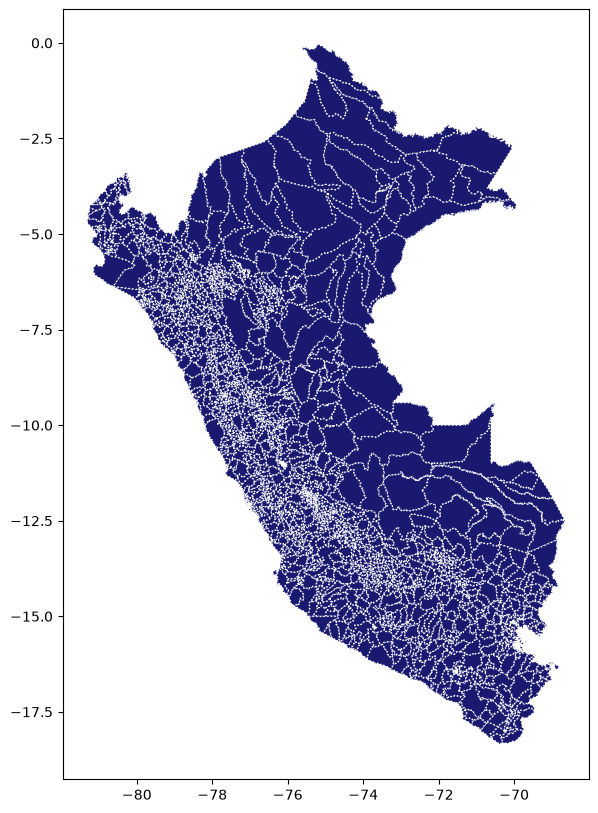

In [23]:
# Plot using geopandas

#figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

maps.plot(  ax=ax, color='midnightblue', linestyle='dotted',
            edgecolor='white' )
plt.show()

## Merge: Covid Data & Shapefile

In [24]:
# Merge using inner way to drop missing values 

dataset_cv = pd.merge(maps, cv_data, how="inner", on="UBIGEO")
dataset_cv

,UBIGEO,geometry,Departamento,Provincia,Distrito,Mes,Año,Casos,Muertes Covid,Muertes totales
0,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,3,2020,0,0,3
1,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,4,2020,0,1,2
2,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,5,2020,1,0,2
3,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,6,2020,7,0,1
4,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,7,2020,11,1,4
...,...,...,...,...,...,...,...,...,...,...
40360,150806,"POLYGON ((-77.3763 -10.89734, -77.37604 -10.89...",LIMA,HUAURA,HUAURA,9,2021,9,0,20
40361,150806,"POLYGON ((-77.3763 -10.89734, -77.37604 -10.89...",LIMA,HUAURA,HUAURA,10,2021,11,2,16
40362,150806,"POLYGON ((-77.3763 -10.89734, -77.37604 -10.89...",LIMA,HUAURA,HUAURA,11,2021,28,1,10
40363,150806,"POLYGON ((-77.3763 -10.89734, -77.37604 -10.89...",LIMA,HUAURA,HUAURA,12,2021,75,1,16


In [25]:
# Panel balanceado: todas las combinaciones UBIGEO x Anho x Mes

# Paso 1: UBIGEOs unicos
ubigeos = dataset_cv['UBIGEO'].unique()

# Paso 2: todas las combinaciones UBIGEO, Anho, Mes
years  = dataset_cv['Anio'].unique() if 'Anio' in dataset_cv.columns else dataset_cv['A\u00f1o'].unique()
months = np.arange(1, 13)

full_index = pd.MultiIndex.from_product(
    [ubigeos, years, months],
    names=["UBIGEO", "A\u00f1o", "Mes"]
)

# Paso 3: indexar el panel original
dataset_cv_balanced = dataset_cv.set_index(["UBIGEO", "A\u00f1o", "Mes"])

# Paso 4: reindexar para balancear
dataset_cv_balanced = dataset_cv_balanced.reindex(full_index).reset_index()

# Paso 5: rellenar numericas con 0 (NO con la cadena "nan": eso convertia
# la columna a texto y rompia todos los mapas por 'Casos' mas abajo)
numeric_cols = ["Casos", "Muertes Covid", "Muertes totales"]
dataset_cv_balanced[numeric_cols] = (
    dataset_cv_balanced[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
)

# Propagar identificadores geograficos dentro de cada distrito
location_cols = ["Departamento", "Provincia", "Distrito", "geometry"]
dataset_cv_balanced = dataset_cv_balanced.sort_values(["UBIGEO", "A\u00f1o", "Mes"])
dataset_cv_balanced[location_cols] = dataset_cv_balanced.groupby("UBIGEO")[location_cols].ffill()

# Reconstruir el GeoDataFrame: reindex() devuelve un DataFrame plano y se
# pierde tanto la geometria activa como el CRS
dataset_cv_balanced = gpd.GeoDataFrame(
    dataset_cv_balanced, geometry="geometry", crs=maps.crs
)

print(dataset_cv_balanced[numeric_cols].dtypes)
dataset_cv_balanced

Casos              float64
Muertes Covid      float64
Muertes totales    float64
dtype: object


,UBIGEO,Año,Mes,geometry,Departamento,Provincia,Distrito,Casos,Muertes Covid,Muertes totales
19188,10101,2020,1,None,NaN,NaN,NaN,0.0,0.0,0.0
19189,10101,2020,2,None,NaN,NaN,NaN,0.0,0.0,0.0
19190,10101,2020,3,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,0.0,0.0,16.0
19191,10101,2020,4,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,47.0,0.0,5.0
19192,10101,2020,5,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,165.0,3.0,11.0
...,...,...,...,...,...,...,...,...,...,...
48307,250401,2022,8,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,0.0,0.0,0.0
48308,250401,2022,9,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,0.0,0.0,0.0
48309,250401,2022,10,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,0.0,0.0,0.0
48310,250401,2022,11,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,0.0,0.0,0.0


In [26]:
# Check if there are missing values in the location columns
missing_locations = dataset_cv_balanced[location_cols].isna().any(axis=1).sum()
print(f"Rows with missing location data: {missing_locations}")

# Fill missing location data by UBIGEO (district identifier)
# Sort by UBIGEO, Year, and Month to ensure proper forward and backward filling
dataset_cv_balanced = dataset_cv_balanced.sort_values(["UBIGEO", "Año", "Mes"])

# First, try forward fill within each UBIGEO group
dataset_cv_balanced[location_cols] = dataset_cv_balanced.groupby("UBIGEO")[location_cols].ffill()

# Then backward fill to handle cases where the first entries might be NaN
dataset_cv_balanced[location_cols] = dataset_cv_balanced.groupby("UBIGEO")[location_cols].bfill()

# Check if there are still missing values after filling
still_missing = dataset_cv_balanced[location_cols].isna().any(axis=1).sum()
print(f"Rows with missing location data after filling: {still_missing}")

# If there are still missing values, we can try to fill them from the maps DataFrame
if still_missing > 0:
    # Only keep the geometry from maps dataframe
    geometry_only = maps[['UBIGEO', 'geometry']].set_index('UBIGEO')
    
    # Fill missing geometries
    missing_geometry = dataset_cv_balanced['geometry'].isna()
    if missing_geometry.any():
        dataset_cv_balanced.loc[missing_geometry, 'geometry'] = dataset_cv_balanced.loc[missing_geometry, 'UBIGEO'].map(geometry_only['geometry'])
    
    # For other location columns, we need to get the information from dataset_cv
    for col in ['Departamento', 'Provincia', 'Distrito']:
        if dataset_cv_balanced[col].isna().any():
            # Create a mapping from UBIGEO to the column
            col_mapping = dataset_cv.drop_duplicates('UBIGEO').set_index('UBIGEO')[col]
            # Apply the mapping to fill missing values
            dataset_cv_balanced.loc[dataset_cv_balanced[col].isna(), col] = dataset_cv_balanced.loc[dataset_cv_balanced[col].isna(), 'UBIGEO'].map(col_mapping)

# Print final status
final_missing = dataset_cv_balanced[location_cols].isna().any(axis=1).sum()
print(f"Rows with missing location data after all filling operations: {final_missing}")

# Show sample of the balanced panel
dataset_cv_balanced

Rows with missing location data: 3510
Rows with missing location data after filling: 0
Rows with missing location data after all filling operations: 0


,UBIGEO,Año,Mes,geometry,Departamento,Provincia,Distrito,Casos,Muertes Covid,Muertes totales
19188,10101,2020,1,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,0.0,0.0,0.0
19189,10101,2020,2,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,0.0,0.0,0.0
19190,10101,2020,3,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,0.0,0.0,16.0
19191,10101,2020,4,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,47.0,0.0,5.0
19192,10101,2020,5,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,165.0,3.0,11.0
...,...,...,...,...,...,...,...,...,...,...
48307,250401,2022,8,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,0.0,0.0,0.0
48308,250401,2022,9,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,0.0,0.0,0.0
48309,250401,2022,10,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,0.0,0.0,0.0
48310,250401,2022,11,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,0.0,0.0,0.0


In [27]:
# Filtra el panel por anho, mes y provincia. "All-Peru" = sin filtro provincial.

def subdata(anio, mes, provincia):
    """Devuelve un GeoDataFrame filtrado, listo para .plot()."""
    m = (dataset_cv_balanced['A\u00f1o'] == anio) & (dataset_cv_balanced['Mes'] == mes)
    if provincia != "All-Peru":
        m &= (dataset_cv_balanced['Provincia'] == provincia)
    # .copy() evita el SettingWithCopyWarning al agregar columnas despues
    return dataset_cv_balanced.loc[m].copy()

In [28]:
#base.Provincia.unique()
base_lima = subdata( 2020 , 8, "LIMA")  # Lima Aug-2020

base_lima


,UBIGEO,Año,Mes,geometry,Departamento,Provincia,Distrito,Casos,Muertes Covid,Muertes totales
43423,150101,2020,8,"POLYGON ((-77.00474 -12.04166, -77.00296 -12.0...",LIMA,LIMA,LIMA,6510.0,658.0,666.0
14227,150102,2020,8,"POLYGON ((-77.06517 -11.57512, -77.06505 -11.5...",LIMA,LIMA,ANCON,460.0,30.0,51.0
43531,150103,2020,8,"POLYGON ((-76.83508 -11.99627, -76.83467 -11.9...",LIMA,LIMA,ATE,3969.0,382.0,545.0
35035,150104,2020,8,"POLYGON ((-77.01945 -12.1306, -77.01915 -12.13...",LIMA,LIMA,BARRANCO,298.0,26.0,62.0
41299,150105,2020,8,"POLYGON ((-77.04206 -12.05348, -77.04198 -12.0...",LIMA,LIMA,BRE<d1>A,1129.0,95.0,180.0
23551,150106,2020,8,"POLYGON ((-76.89995 -11.72979, -76.89921 -11.7...",LIMA,LIMA,CARABAYLLO,2054.0,183.0,281.0
43567,150107,2020,8,"POLYGON ((-76.72918 -11.96426, -76.72809 -11.9...",LIMA,LIMA,CHACLACAYO,512.0,31.0,62.0
34927,150108,2020,8,"POLYGON ((-77.00745 -12.16033, -77.00781 -12.1...",LIMA,LIMA,CHORRILLOS,2400.0,203.0,333.0
41731,150109,2020,8,"POLYGON ((-76.72948 -11.99943, -76.72596 -11.9...",LIMA,LIMA,CIENEGUILLA,161.0,12.0,25.0
43747,150110,2020,8,"POLYGON ((-77.04639 -11.89743, -77.04551 -11.8...",LIMA,LIMA,COMAS,4323.0,533.0,753.0


In [29]:
#Second wave 
base = subdata( 2020 , 8, "All-Peru")  # all peru Aug-2020

#Second wave only Lima
base_lima = subdata( 2020 , 8, "LIMA")  # Lima Aug-2020

#Second wave only Lima
base_ayacucho = subdata( 2020 , 10, "LUCANAS")  # Lima Aug-2020

In [30]:
base_ayacucho

,UBIGEO,Año,Mes,geometry,Departamento,Provincia,Distrito,Casos,Muertes Covid,Muertes totales
60705,50601,2020,10,"POLYGON ((-74.09914 -14.51889, -74.09729 -14.5...",AYACUCHO,LUCANAS,PUQUIO,46.0,1.0,1.0
60597,50602,2020,10,"POLYGON ((-74.06654 -14.02992, -74.06581 -14.0...",AYACUCHO,LUCANAS,AUCARA,5.0,1.0,2.0
60237,50603,2020,10,"POLYGON ((-73.89004 -14.26761, -73.88869 -14.2...",AYACUCHO,LUCANAS,CABANA,0.0,0.0,0.0
60345,50604,2020,10,"POLYGON ((-73.93008 -14.3235, -73.92803 -14.32...",AYACUCHO,LUCANAS,CARMEN SALCEDO,2.0,0.0,2.0
59517,50605,2020,10,"POLYGON ((-73.8766 -14.80292, -73.87742 -14.80...",AYACUCHO,LUCANAS,CHAVI<d1>A,0.0,0.0,2.0
60165,50606,2020,10,"POLYGON ((-73.85391 -14.2781, -73.85018 -14.28...",AYACUCHO,LUCANAS,CHIPAO,2.0,0.0,1.0
60453,50608,2020,10,"POLYGON ((-74.67672 -14.07173, -74.67674 -14.0...",AYACUCHO,LUCANAS,LARAMATE,0.0,0.0,0.0
60129,50609,2020,10,"POLYGON ((-74.43725 -14.52504, -74.43454 -14.5...",AYACUCHO,LUCANAS,LEONCIO PRADO,1.0,0.0,0.0
60489,50610,2020,10,"POLYGON ((-74.85561 -14.07523, -74.85274 -14.0...",AYACUCHO,LUCANAS,LLAUTA,0.0,0.0,0.0
60201,50611,2020,10,"POLYGON ((-74.27602 -14.27152, -74.27477 -14.2...",AYACUCHO,LUCANAS,LUCANAS,0.0,0.0,2.0


In [31]:
base

,UBIGEO,Año,Mes,geometry,Departamento,Provincia,Distrito,Casos,Muertes Covid,Muertes totales
19195,10101,2020,8,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,445.0,15.0,29.0
10375,10103,2020,8,"POLYGON ((-77.93289 -6.6921, -77.92945 -6.6921...",AMAZONAS,CHACHAPOYAS,BALSAS,7.0,0.0,0.0
20131,10105,2020,8,"POLYGON ((-77.7387 -6.02799, -77.73739 -6.0287...",AMAZONAS,CHACHAPOYAS,CHILIQUIN,1.0,0.0,0.0
47887,10106,2020,8,"POLYGON ((-77.85853 -6.87111, -77.85695 -6.871...",AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,0.0,0.0,3.0
19951,10108,2020,8,"POLYGON ((-77.87976 -6.10233, -77.87888 -6.102...",AMAZONAS,CHACHAPOYAS,HUANCAS,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
115,250302,2020,8,"POLYGON ((-75.13864 -8.56712, -75.13956 -8.569...",UCAYALI,PADRE ABAD,IRAZOLA,48.0,2.0,4.0
223,250303,2020,8,"POLYGON ((-75.43663 -8.22999, -75.43651 -8.230...",UCAYALI,PADRE ABAD,CURIMANA,65.0,2.0,2.0
151,250304,2020,8,"POLYGON ((-75.01589 -8.44637, -75.01585 -8.446...",UCAYALI,PADRE ABAD,NESHUYA,53.0,2.0,3.0
79,250305,2020,8,"POLYGON ((-75.02253 -8.74193, -75.02267 -8.742...",UCAYALI,PADRE ABAD,ALEXANDER VON HUMBOLDT,3.0,2.0,1.0


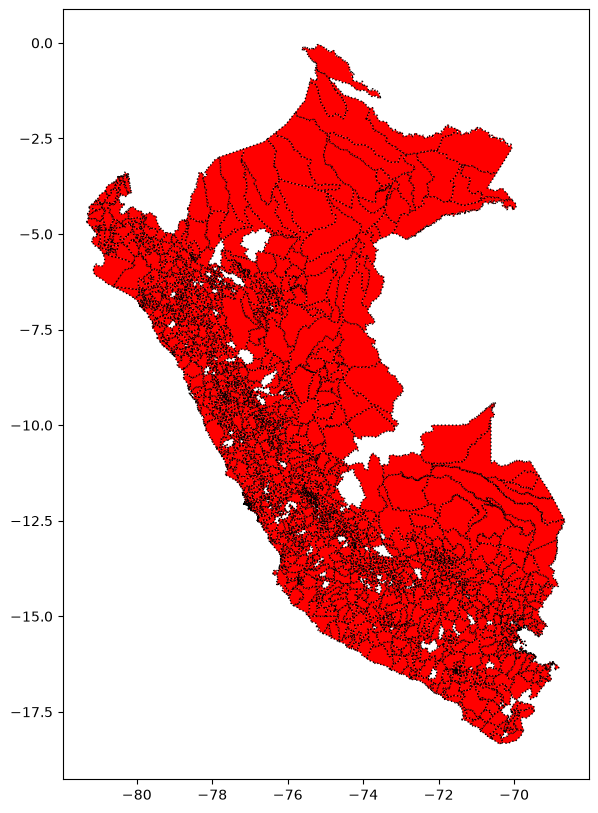

In [32]:
fig, ax = plt.subplots(figsize=(10,10))

base.plot(  ax=ax, color='red', linestyle='dotted',
            edgecolor='black' )
plt.show()

#does not picture the provinces who dont have covid cases.

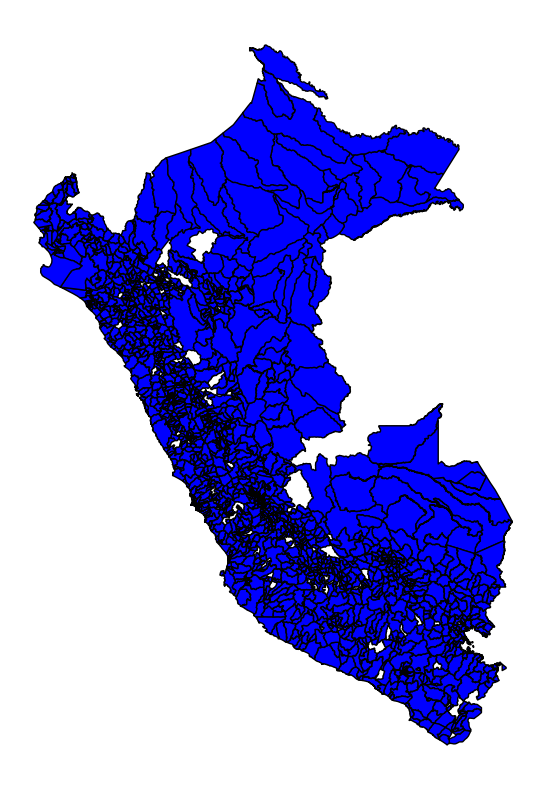

In [33]:
# Plot without axis

fig, ax = plt.subplots(figsize=(10, 10))
base.plot(ax=ax,color='blue', linestyle='-',
                      edgecolor='black')
ax.set_axis_off()

## Plot covid infection at disctrict level 

<Axes: >

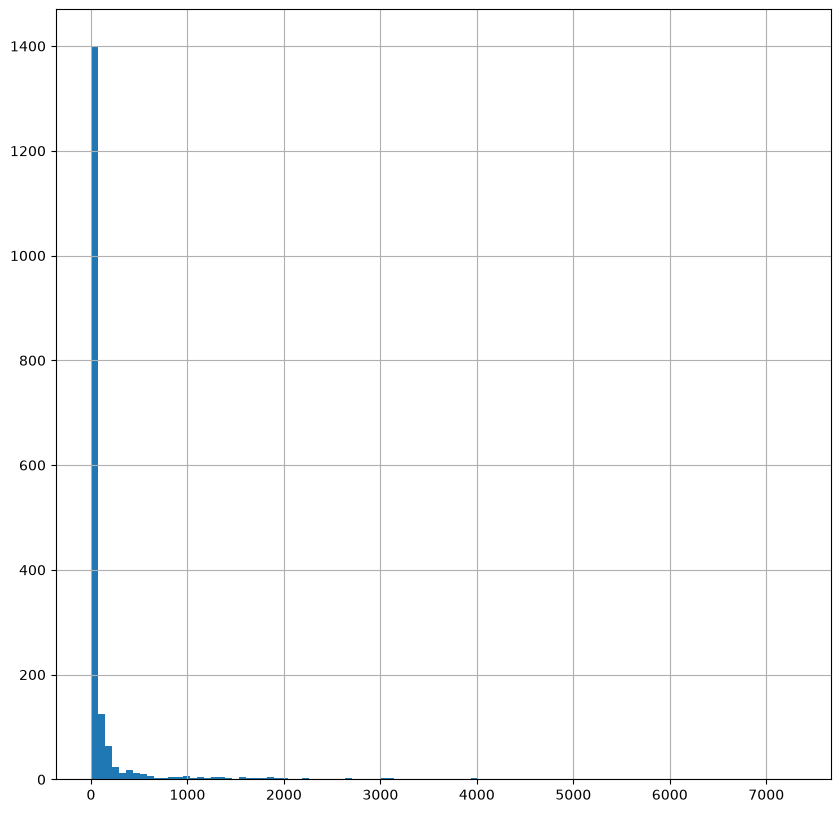

In [34]:
# First always check the distribution
fig, ax = plt.subplots(figsize=(10, 10))
base["Casos"].hist(bins = 100)

#check the distribution of the variables BEFORE PLOTTING

<Axes: >

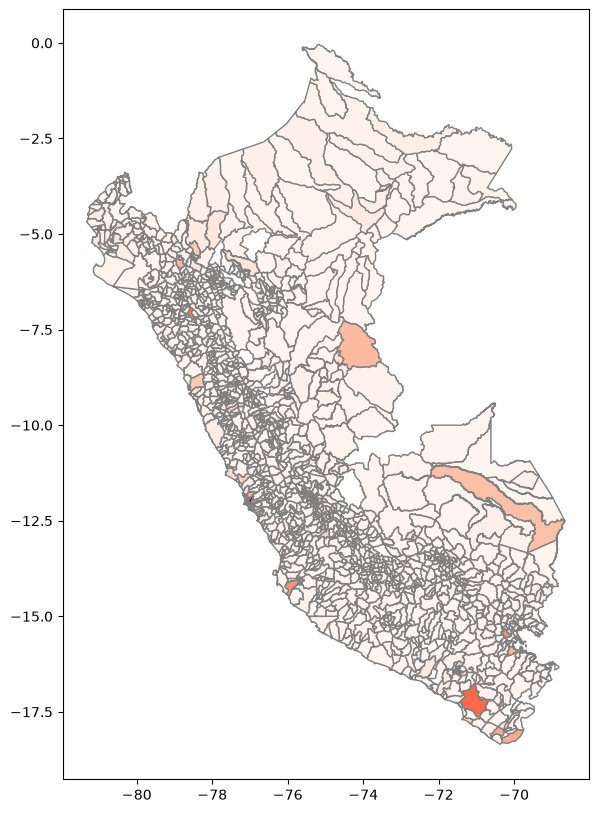

In [35]:
# Plot covid infection at disctrict level 

base.plot( column='Casos', cmap='Reds', 
          figsize=(10, 10),
          linestyle='-',
          edgecolor='gray')

<Axes: >

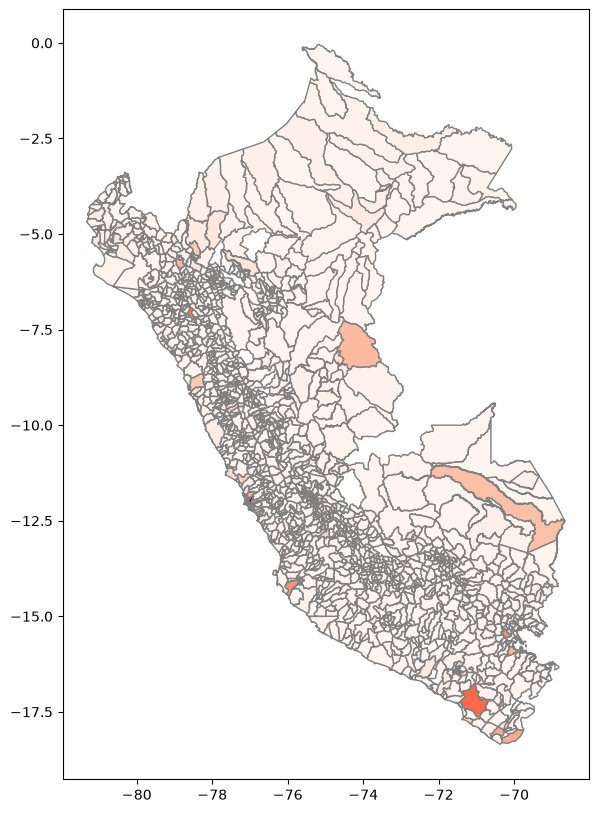

In [36]:
base.plot(
    column='Casos', cmap='Reds',
    figsize=(10, 10),
    linestyle='-',
    edgecolor='gray',
    missing_kwds={
        'color': 'lightgrey',
        'edgecolor': 'gray',
        'hatch': '///',
        'label': 'No data'
    }
)


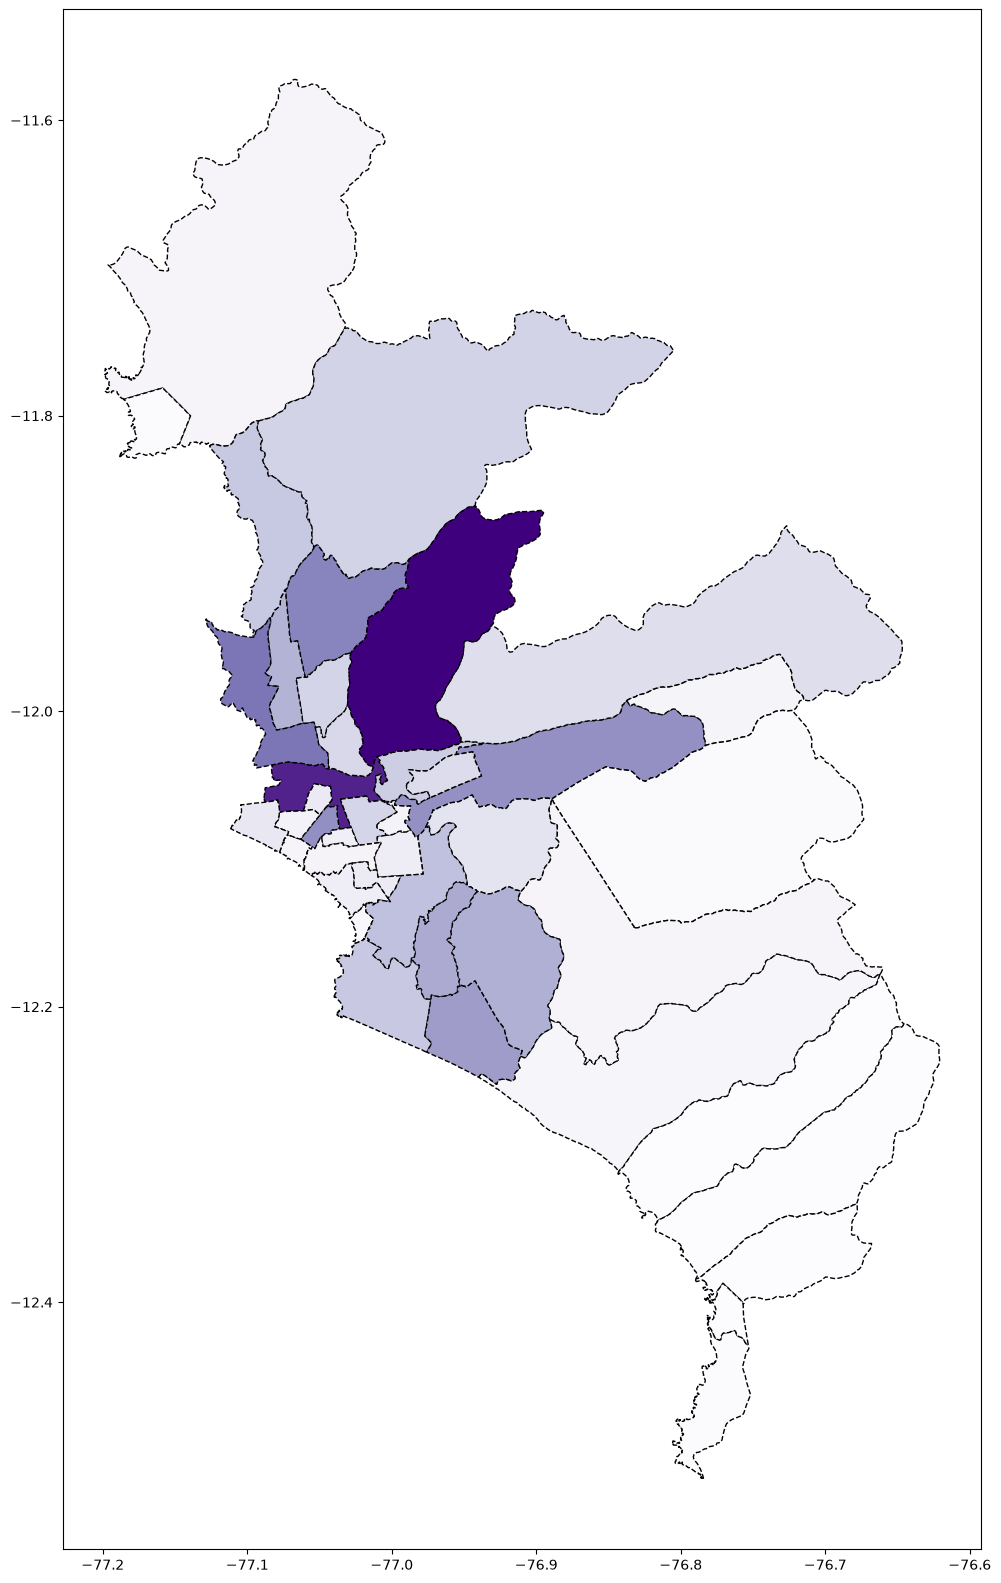

In [37]:
# Covid & Lima Matropolitana 

base_lima.plot(column='Casos', cmap='Purples', figsize=(20, 20), linestyle='--',
                      edgecolor='black')

# save map
plt.savefig(r'Lima_covid_Heatmap.png')

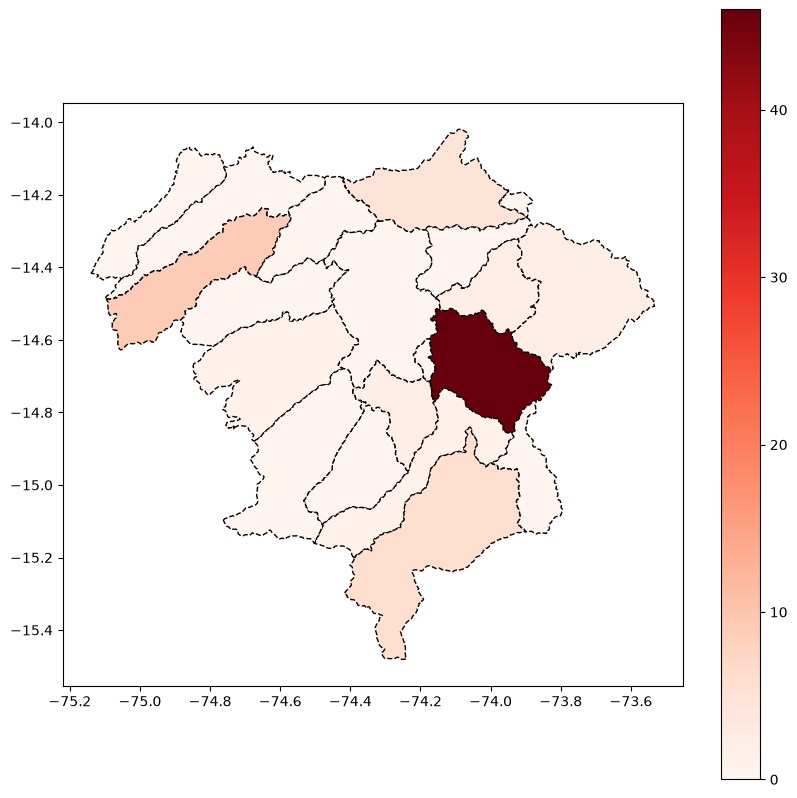

In [38]:
# Covid & Lima Matropolitana 

base_ayacucho.plot(column='Casos', cmap='Reds', figsize=(10, 10), linestyle='--',
                      edgecolor='black', 
                      legend = True)

# save map
plt.savefig(r'Ayacucho_covid_Heatmap.png')

In [39]:
base_lima.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Get Centroid

In [40]:
base_lima['geometry']

43423    POLYGON ((-77.00474 -12.04166, -77.00296 -12.0...
14227    POLYGON ((-77.06517 -11.57512, -77.06505 -11.5...
43531    POLYGON ((-76.83508 -11.99627, -76.83467 -11.9...
35035    POLYGON ((-77.01945 -12.1306, -77.01915 -12.13...
41299    POLYGON ((-77.04206 -12.05348, -77.04198 -12.0...
23551    POLYGON ((-76.89995 -11.72979, -76.89921 -11.7...
43567    POLYGON ((-76.72918 -11.96426, -76.72809 -11.9...
34927    POLYGON ((-77.00745 -12.16033, -77.00781 -12.1...
41731    POLYGON ((-76.72948 -11.99943, -76.72596 -11.9...
43747    POLYGON ((-77.04639 -11.89743, -77.04551 -11.8...
43459    POLYGON ((-76.94408 -12.02075, -76.94348 -12.0...
43603    POLYGON ((-77.02858 -11.96462, -77.02794 -11.9...
33775    POLYGON ((-77.03811 -12.06768, -77.03629 -12.0...
41227    POLYGON ((-76.94006 -12.06405, -76.93942 -12.0...
41191    POLYGON ((-77.01661 -12.05889, -77.01559 -12.0...
18403    POLYGON ((-77.02807 -12.07871, -77.02435 -12.0...
43711    POLYGON ((-77.07044 -11.95013, -77.07008 -11.9.

In [41]:
# Centroid (point in the center)

#base_lima = base_lima.to_crs("EPSG:32733")
#WGS84 (MAP IN CURVE) > PROJ IN METER "EPSG:24891" TO CALCULATE CENTROID > CONVERT TO CURVE AGAIN (THE CENTROID CAN BE OUT BECAUSE IF THE IMAGE IS CONCAVA)


base_lima['centroid'] = base_lima['geometry'].to_crs("EPSG:24891").centroid.to_crs("EPSG:4326")

In [42]:
base_lima

,UBIGEO,Año,Mes,geometry,Departamento,Provincia,Distrito,Casos,Muertes Covid,Muertes totales,centroid
43423,150101,2020,8,"POLYGON ((-77.00474 -12.04166, -77.00296 -12.0...",LIMA,LIMA,LIMA,6510.0,658.0,666.0,POINT (-77.04887 -12.05103)
14227,150102,2020,8,"POLYGON ((-77.06517 -11.57512, -77.06505 -11.5...",LIMA,LIMA,ANCON,460.0,30.0,51.0,POINT (-77.0958 -11.70252)
43531,150103,2020,8,"POLYGON ((-76.83508 -11.99627, -76.83467 -11.9...",LIMA,LIMA,ATE,3969.0,382.0,545.0,POINT (-76.87747 -12.03257)
35035,150104,2020,8,"POLYGON ((-77.01945 -12.1306, -77.01915 -12.13...",LIMA,LIMA,BARRANCO,298.0,26.0,62.0,POINT (-77.02086 -12.14403)
41299,150105,2020,8,"POLYGON ((-77.04206 -12.05348, -77.04198 -12.0...",LIMA,LIMA,BRE<d1>A,1129.0,95.0,180.0,POINT (-77.05059 -12.05916)
23551,150106,2020,8,"POLYGON ((-76.89995 -11.72979, -76.89921 -11.7...",LIMA,LIMA,CARABAYLLO,2054.0,183.0,281.0,POINT (-76.97291 -11.80738)
43567,150107,2020,8,"POLYGON ((-76.72918 -11.96426, -76.72809 -11.9...",LIMA,LIMA,CHACLACAYO,512.0,31.0,62.0,POINT (-76.76695 -11.99164)
34927,150108,2020,8,"POLYGON ((-77.00745 -12.16033, -77.00781 -12.1...",LIMA,LIMA,CHORRILLOS,2400.0,203.0,333.0,POINT (-77.00589 -12.19265)
41731,150109,2020,8,"POLYGON ((-76.72948 -11.99943, -76.72596 -11.9...",LIMA,LIMA,CIENEGUILLA,161.0,12.0,25.0,POINT (-76.77752 -12.07646)
43747,150110,2020,8,"POLYGON ((-77.04639 -11.89743, -77.04551 -11.8...",LIMA,LIMA,COMAS,4323.0,533.0,753.0,POINT (-77.0389 -11.92906)


In [43]:
# fig, ax = plt.subplots(figsize=(20, 20))

# # Heatmap Lima and Covid infection

# base_lima.plot(column='Casos', cmap='Reds', linestyle='--',
#                       edgecolor='black', 
#                       legend = True, ax=ax)

## Add District Names in Centroid

In [44]:
#base_lima['centroid']

In [45]:
# for point in base_lima.iterrows():
#     print(point[1]['Distrito'])

In [46]:
props = dict(boxstyle='round', facecolor = 'linen', alpha =1)

In [47]:
props

{'boxstyle': 'round', 'facecolor': 'linen', 'alpha': 1}

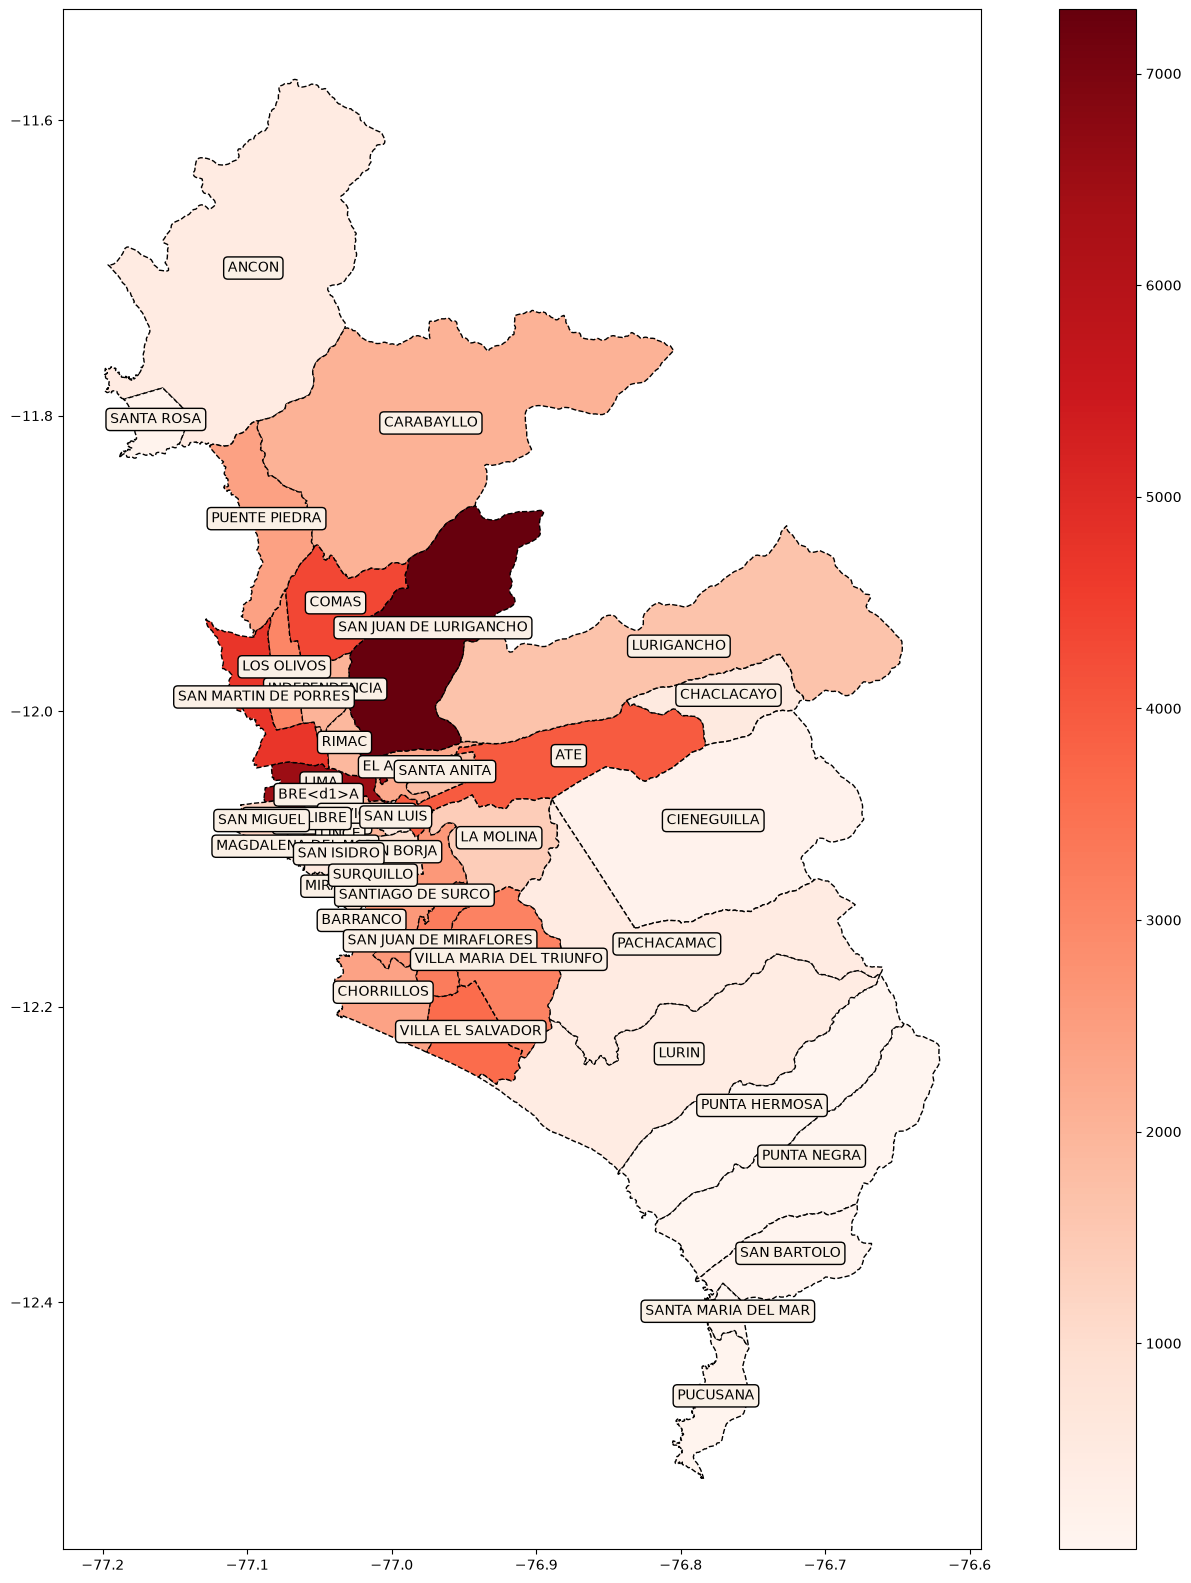

In [48]:
fig, ax = plt.subplots(figsize=(20, 20))

# Heatmap Lima and Covid infection

base_lima.plot(column='Casos', cmap='Reds', linestyle='--',
                      edgecolor='black', 
                      legend = True, ax=ax)

# add district name in litle box

props = dict(boxstyle='round', facecolor = 'linen', alpha =1)

for point in base_lima.iterrows():
        ax.text( point[1]['centroid'].x,
                 point[1]['centroid'].y,
                 point[1]['Distrito'],
                 horizontalalignment='center',
                 fontsize=10,
                 bbox=props )

plt.savefig(r'Lima_covid_Heatmap_2.png')
#plot.savefig(r'Lima_covid_Heatmap_2.png')

<Axes: >

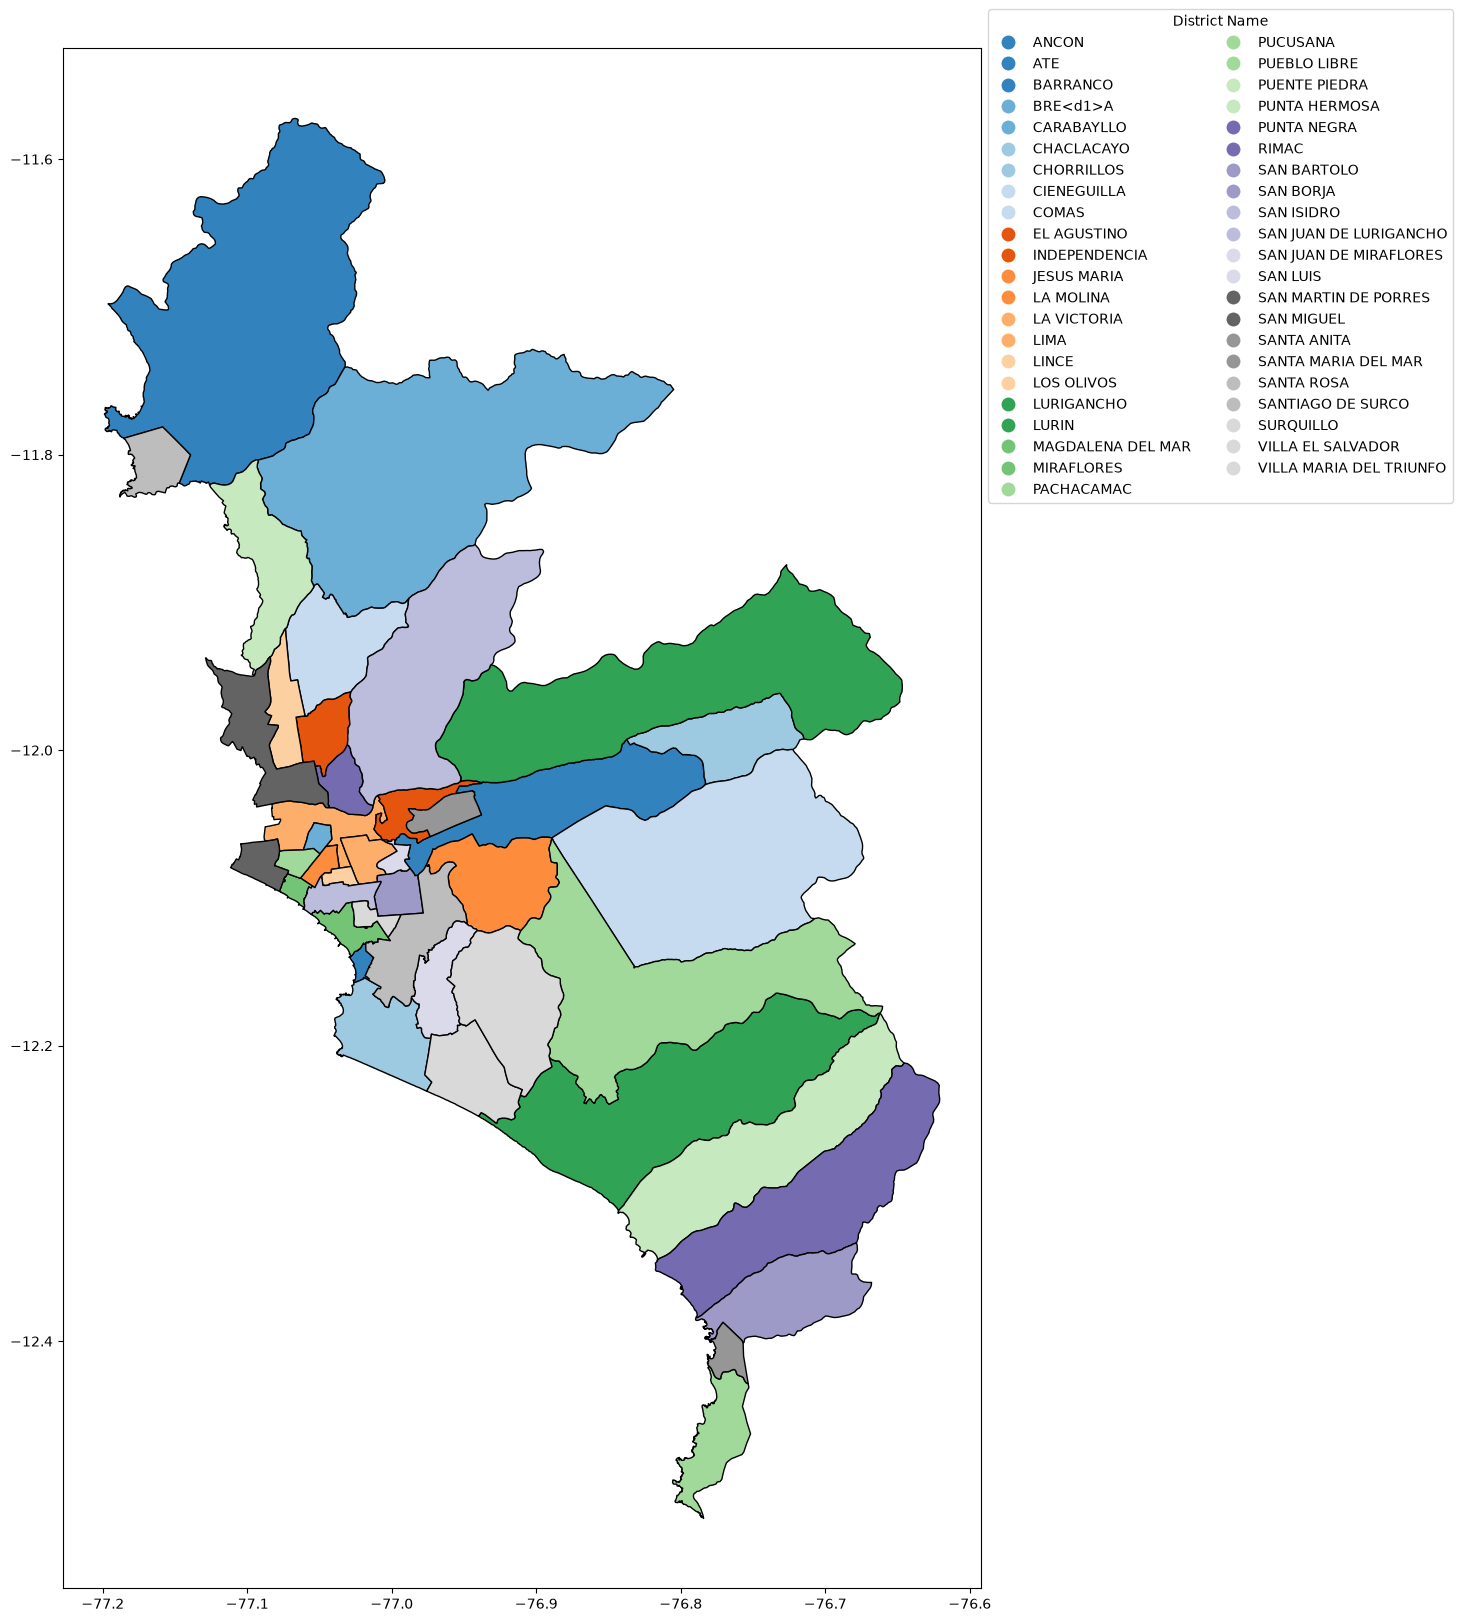

In [49]:
# Using legend by district 

leg_kwds={'title':'District Name',
          'loc': 'upper left',
          'bbox_to_anchor':(1, 1.03),
          'ncol':2}


base_lima.plot(column='Distrito', cmap='tab20c', figsize=(20, 20), legend = True, linestyle='-', 
               edgecolor='black',
               legend_kwds = leg_kwds)

## Public Health Centers Data

In [50]:
base_lima.geometry.iloc[1:2]

#NOTH (x), EAST(Y)

14227    POLYGON ((-77.06517 -11.57512, -77.06505 -11.5...
Name: geometry, dtype: geometry

In [51]:
# Centros de salud publicos: MINSA, ESSALUD y Gobiernos Regionales
# NORTE = longitud, ESTE = latitud (grados decimales, pese a los nombres)

# El notebook vive en Lectures/Lecture_5/, asi que _data esta dos niveles arriba
health_centers = pd.read_csv(r'../../_data/centros_hospitalarios.csv', encoding='utf-8-sig')
health_centers.head(5)

,Institución,Código Único,Nombre del establecimiento,Clasificación,Tipo,Departamento,Provincia,Distrito,UBIGEO,Dirección,...,Estado,Situación,Condición,Inspección,NORTE,ESTE,COTA,CAMAS,code1,code2
0,GOBIERNO REGIONAL,2076,SAN PABLO,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,LAMBAYEQUE S/N NEGRITOS,...,ACTIVADO,,EN FUNCIONAMIENTO,,-81.310632,-4.665043,15.3,NaN,19,1
1,ESSALUD,20628,POSTA MEDICA NEGRITOS,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,AVENIDA SAN MARTIN Nº 100 NEGRITOS,...,ACTIVADO,,EN FUNCIONAMIENTO,,-81.306508,-4.654384,20.4,NaN,19,1
2,GOBIERNO REGIONAL,2075,NEGRITOS,CENTROS DE SALUD O CENTROS MEDICOS,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,URB. SUD AMERICA D-14 TALARA,...,ACTIVADO,,EN FUNCIONAMIENTO,,-81.303974,-4.658634,41.6,NaN,4,1
3,GOBIERNO REGIONAL,2077,LOBITOS,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LOBITOS,200704,BARRIO PRIMAVERA A- 100 LOBITOS,...,ACTIVADO,,EN FUNCIONAMIENTO,,-81.275139,-4.456625,39.4,NaN,19,1
4,ESSALUD,12243,HOSPITAL II ESSALUD TALARA,HOSPITALES O CLINICAS DE ATENCION GENERAL,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,PIURA,TALARA,PARIÑAS,200701,AV. PANAMERICANA S/N CARRETERA A LOBITOS,...,ACTIVADO,,EN FUNCIONAMIENTO,,-81.273840,-4.568419,28.7,35.0,12,3


In [52]:
health_centers.columns

Index(['Institución', 'Código Único', 'Nombre del establecimiento',
       'Clasificación', 'Tipo', 'Departamento', 'Provincia', 'Distrito',
       'UBIGEO', 'Dirección', 'Código DISA', 'Código Red', 'Código Microrred',
       'DISA', 'Red', 'Microrred', 'Código UE', 'Unidad Ejecutora',
       'Categoria', 'Teléfono', 'Tipo Doc.Categorización',
       'Nro.Doc.Categorización', 'Horario', 'Inicio de Actividad',
       'Director Médico y/o Responsable de la Atención de Salud', 'Estado',
       'Situación', 'Condición', 'Inspección', 'NORTE', 'ESTE', 'COTA',
       'CAMAS', 'code1', 'code2'],
      dtype='str')

In [53]:
health_centers.NORTE

0      -81.310632
1      -81.306508
2      -81.303974
3      -81.275139
4      -81.273840
          ...    
8459          NaN
8460          NaN
8461          NaN
8462          NaN
8463          NaN
Name: NORTE, Length: 8464, dtype: float64

In [54]:
# DataFrame to GeoDataFrame

Public_health = gpd.GeoDataFrame( health_centers, geometry=gpd.points_from_xy( health_centers.NORTE, health_centers.ESTE ) )
Public_health.head( 5 )

,Institución,Código Único,Nombre del establecimiento,Clasificación,Tipo,Departamento,Provincia,Distrito,UBIGEO,Dirección,...,Situación,Condición,Inspección,NORTE,ESTE,COTA,CAMAS,code1,code2,geometry
0,GOBIERNO REGIONAL,2076,SAN PABLO,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,LAMBAYEQUE S/N NEGRITOS,...,,EN FUNCIONAMIENTO,,-81.310632,-4.665043,15.3,NaN,19,1,POINT (-81.31063 -4.66504)
1,ESSALUD,20628,POSTA MEDICA NEGRITOS,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,AVENIDA SAN MARTIN Nº 100 NEGRITOS,...,,EN FUNCIONAMIENTO,,-81.306508,-4.654384,20.4,NaN,19,1,POINT (-81.30651 -4.65438)
2,GOBIERNO REGIONAL,2075,NEGRITOS,CENTROS DE SALUD O CENTROS MEDICOS,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,URB. SUD AMERICA D-14 TALARA,...,,EN FUNCIONAMIENTO,,-81.303974,-4.658634,41.6,NaN,4,1,POINT (-81.30397 -4.65863)
3,GOBIERNO REGIONAL,2077,LOBITOS,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LOBITOS,200704,BARRIO PRIMAVERA A- 100 LOBITOS,...,,EN FUNCIONAMIENTO,,-81.275139,-4.456625,39.4,NaN,19,1,POINT (-81.27514 -4.45663)
4,ESSALUD,12243,HOSPITAL II ESSALUD TALARA,HOSPITALES O CLINICAS DE ATENCION GENERAL,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,PIURA,TALARA,PARIÑAS,200701,AV. PANAMERICANA S/N CARRETERA A LOBITOS,...,,EN FUNCIONAMIENTO,,-81.273840,-4.568419,28.7,35.0,12,3,POINT (-81.27384 -4.56842)


In [55]:
# NORTE/ESTE estan en grados decimales (lon entre -81 y -68, lat entre -18 y 0),
# no en metros UTM. Asignar EPSG:32718 colocaba los puntos fuera del planeta.
Public_health = Public_health.set_crs("EPSG:4326", allow_override=True)
Public_health.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [56]:
Public_health.head( 5 )

,Institución,Código Único,Nombre del establecimiento,Clasificación,Tipo,Departamento,Provincia,Distrito,UBIGEO,Dirección,...,Situación,Condición,Inspección,NORTE,ESTE,COTA,CAMAS,code1,code2,geometry
0,GOBIERNO REGIONAL,2076,SAN PABLO,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,LAMBAYEQUE S/N NEGRITOS,...,,EN FUNCIONAMIENTO,,-81.310632,-4.665043,15.3,NaN,19,1,POINT (-81.31063 -4.66504)
1,ESSALUD,20628,POSTA MEDICA NEGRITOS,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,AVENIDA SAN MARTIN Nº 100 NEGRITOS,...,,EN FUNCIONAMIENTO,,-81.306508,-4.654384,20.4,NaN,19,1,POINT (-81.30651 -4.65438)
2,GOBIERNO REGIONAL,2075,NEGRITOS,CENTROS DE SALUD O CENTROS MEDICOS,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,URB. SUD AMERICA D-14 TALARA,...,,EN FUNCIONAMIENTO,,-81.303974,-4.658634,41.6,NaN,4,1,POINT (-81.30397 -4.65863)
3,GOBIERNO REGIONAL,2077,LOBITOS,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LOBITOS,200704,BARRIO PRIMAVERA A- 100 LOBITOS,...,,EN FUNCIONAMIENTO,,-81.275139,-4.456625,39.4,NaN,19,1,POINT (-81.27514 -4.45663)
4,ESSALUD,12243,HOSPITAL II ESSALUD TALARA,HOSPITALES O CLINICAS DE ATENCION GENERAL,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,PIURA,TALARA,PARIÑAS,200701,AV. PANAMERICANA S/N CARRETERA A LOBITOS,...,,EN FUNCIONAMIENTO,,-81.273840,-4.568419,28.7,35.0,12,3,POINT (-81.27384 -4.56842)


## Types and classification public centers

#### We focus on Postas médicas and Hospitales

#### code2 (Type)

ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO:			1

SERVICIO MÉDICO DE APOYO:			                2

ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO:			3


#### code1 (Clasification)

ATENCION PRE HOSPITALARIA:	1

CENTROS DE ATENCION PARA DEPENDIENTES A SUSTANCIAS PSICOACTIVAS Y OTRAS DEPENDENCIAS:	2

CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO:	3

CENTROS DE SALUD O CENTROS MEDICOS:	4

CENTROS DE SALUD O CENTROS MEDICOS,CENTROS DE SALUD O CENTROS MEDICOS:	5

CENTROS DE VACUNACION:	6

CENTROS MEDICOS ESPECIALIZADOS:	7

CONSULTORIOS MEDICOS Y DE OTROS PROFESIONALES DE LA SALUD:	8

ESTABLECIMIENTOS DE RECUPERACION O REPOSO:	9

HEMODIALISIS:	10

HOSPITALES O CLINICAS DE ATENCION ESPECIALIZADA:	11

HOSPITALES O CLINICAS DE ATENCION GENERAL:	12

INSTITUTOS DE SALUD ESPECIALIZADOS:	13

MEDICINA FISICA,REHABILITACION:	14

PATOLOGIA CLINICA:	15

PATOLOGIA CLINICA,ANATOMIA PATOLOGICA:	16

PATOLOGIA CLINICA,DIAGNOSTICO POR IMAGENES:	17

POLICLINICOS:	18

PUESTOS DE SALUD O POSTAS DE SALUD:	19

PUESTOS DE SALUD O POSTAS DE SALUD,PUESTOS DE SALUD O POSTAS DE SALUD:	19

SERVICIO DE TRASLADO DE PACIENTES:	20

SERVICIO DE TRASLADO DE PACIENTES,ATENCION DOMICILIARIA:	21

SERVICIO DE TRASLADO DE PACIENTES,ATENCION DOMICILIARIA,ATENCION PRE HOSPITALARIA:	22

SERVICIO DE TRASLADO DE PACIENTES,ATENCION PRE HOSPITALARIA:	23

CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO:	24


In [57]:
Public_health.head( 5 )

,Institución,Código Único,Nombre del establecimiento,Clasificación,Tipo,Departamento,Provincia,Distrito,UBIGEO,Dirección,...,Situación,Condición,Inspección,NORTE,ESTE,COTA,CAMAS,code1,code2,geometry
0,GOBIERNO REGIONAL,2076,SAN PABLO,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,LAMBAYEQUE S/N NEGRITOS,...,,EN FUNCIONAMIENTO,,-81.310632,-4.665043,15.3,NaN,19,1,POINT (-81.31063 -4.66504)
1,ESSALUD,20628,POSTA MEDICA NEGRITOS,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,AVENIDA SAN MARTIN Nº 100 NEGRITOS,...,,EN FUNCIONAMIENTO,,-81.306508,-4.654384,20.4,NaN,19,1,POINT (-81.30651 -4.65438)
2,GOBIERNO REGIONAL,2075,NEGRITOS,CENTROS DE SALUD O CENTROS MEDICOS,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LA BREA,200703,URB. SUD AMERICA D-14 TALARA,...,,EN FUNCIONAMIENTO,,-81.303974,-4.658634,41.6,NaN,4,1,POINT (-81.30397 -4.65863)
3,GOBIERNO REGIONAL,2077,LOBITOS,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,PIURA,TALARA,LOBITOS,200704,BARRIO PRIMAVERA A- 100 LOBITOS,...,,EN FUNCIONAMIENTO,,-81.275139,-4.456625,39.4,NaN,19,1,POINT (-81.27514 -4.45663)
4,ESSALUD,12243,HOSPITAL II ESSALUD TALARA,HOSPITALES O CLINICAS DE ATENCION GENERAL,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,PIURA,TALARA,PARIÑAS,200701,AV. PANAMERICANA S/N CARRETERA A LOBITOS,...,,EN FUNCIONAMIENTO,,-81.273840,-4.568419,28.7,35.0,12,3,POINT (-81.27384 -4.56842)


In [58]:
# code1 = 19 to postas médicas 
# code1 = 12 & 24 to Hospitals

Public_health1 = Public_health[Public_health.code1 == "19"]

Public_health2 = Public_health[(Public_health.code1 == "12") | (Public_health.code1 == "24")]
Public_health2.head( 5 )

,Institución,Código Único,Nombre del establecimiento,Clasificación,Tipo,Departamento,Provincia,Distrito,UBIGEO,Dirección,...,Situación,Condición,Inspección,NORTE,ESTE,COTA,CAMAS,code1,code2,geometry
4,ESSALUD,12243,HOSPITAL II ESSALUD TALARA,HOSPITALES O CLINICAS DE ATENCION GENERAL,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,PIURA,TALARA,PARIÑAS,200701,AV. PANAMERICANA S/N CARRETERA A LOBITOS,...,,EN FUNCIONAMIENTO,,-81.273840,-4.568419,28.7,35.0,12,3,POINT (-81.27384 -4.56842)
5,GOBIERNO REGIONAL,2074,TALARA II,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,PIURA,TALARA,PARIÑAS,200701,AVENIDA GRAU S/N EXPOLICLINICO PETROPERU,...,,EN FUNCIONAMIENTO,,-81.272096,-4.578829,21.1,NaN,24,3,POINT (-81.2721 -4.57883)
19,ESSALUD,11763,HOSPITAL I MIGUEL CRUZADO VERA - PAITA,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,PIURA,PAITA,PAITA,200501,CARRETERA PAITA - PIURA KM 1.5,...,,EN FUNCIONAMIENTO,,-81.100243,-5.087583,75.9,12.0,24,3,POINT (-81.10024 -5.08758)
20,GOBIERNO REGIONAL,2021,HOSPITAL LAS MERCEDES-PAITA,HOSPITALES O CLINICAS DE ATENCION GENERAL,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,PIURA,PAITA,PAITA,200501,LOS PESCADORES S/N LA PUNTA,...,,EN FUNCIONAMIENTO,,-81.091531,-5.090815,78.3,79.0,12,3,POINT (-81.09153 -5.09081)
23,GOBIERNO REGIONAL,2026,PUEBLO NUEVO DE COLAN,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,PIURA,PAITA,COLAN,200504,JR. ALFONSO UGARTE S/N,...,,EN FUNCIONAMIENTO,,-81.058005,-4.911551,16.6,NaN,24,3,POINT (-81.05801 -4.91155)


In [59]:
# # Quantiles quantity of infection 

# base_lima.plot(column='Casos', cmap='Set2', figsize=(20, 20), linestyle=':', 
#                edgecolor='black',
#                legend = True)

In [60]:
# Postas Médicas and Hospitales públicos - LIMA

PH_lima_postas = Public_health1[Public_health1.Provincia == "LIMA"]

PH_lima_hospitales = Public_health2[Public_health2.Provincia == "LIMA"]
PH_lima_hospitales

,Institución,Código Único,Nombre del establecimiento,Clasificación,Tipo,Departamento,Provincia,Distrito,UBIGEO,Dirección,...,Situación,Condición,Inspección,NORTE,ESTE,COTA,CAMAS,code1,code2,geometry
2715,MINSA,5814,CENTRO DE SALUD MATERNO INFANTIL ANCON,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,LIMA,LIMA,ANCON,150102,JR. LOA 595 ANCON,...,,EN FUNCIONAMIENTO,,-77.172725,-11.774719,12.0,NaN,24,3,POINT (-77.17272 -11.77472)
2803,MINSA,5816,MATERNO INFANTIL DR. ENRIQUE MARTIN ALTUNA,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,LIMA,LIMA,PUENTE PIEDRA,150125,ASOC VIV E INDUSTRIAS VIRGEN DE LAS NIEVES URB...,...,,EN FUNCIONAMIENTO,,-77.109100,-11.837611,200.0,NaN,24,3,POINT (-77.1091 -11.83761)
2832,ESSALUD,8564,HOSPITAL I OCTAVIO MONGRUT MUÑOZ,HOSPITALES O CLINICAS DE ATENCION GENERAL,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,LIMA,LIMA,SAN MIGUEL,150136,AV PARQUE DE LAS LEYENDAS 255,...,,EN FUNCIONAMIENTO,,-77.094583,-12.065961,NaN,49.0,12,3,POINT (-77.09458 -12.06596)
2852,MINSA,5817,SANTA ROSA,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,LIMA,LIMA,PUENTE PIEDRA,150125,"AA.HH. SANTA ROSA, MZ. 50, LOTE PM - AV. SANTA...",...,,EN FUNCIONAMIENTO,,-77.081693,-11.874827,200.0,NaN,24,3,POINT (-77.08169 -11.87483)
2859,MINSA,7632,HOSPITAL CARLOS LANFRANCO LA HOZ,HOSPITALES O CLINICAS DE ATENCION GENERAL,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,LIMA,LIMA,PUENTE PIEDRA,150125,AV. SAENZ PEÑA - CUADRA 6 S/N,...,,EN FUNCIONAMIENTO,,-77.079335,-11.863181,NaN,102.0,12,3,POINT (-77.07934 -11.86318)
2862,MINSA,5799,CLAS JUAN PABLO II,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,LIMA,LIMA,LOS OLIVOS,150117,CALLE 28 S/N AA.HH. JUAN PABLO II,...,,EN FUNCIONAMIENTO,,-77.078891,-11.953212,63.0,NaN,24,3,POINT (-77.07889 -11.95321)
2875,MINSA,5821,LOS SUREÑOS,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,LIMA,LIMA,PUENTE PIEDRA,150125,COOP. VIVIENDA LOS SUREÑOS MZ M LT. 35,...,,EN FUNCIONAMIENTO,,-77.069701,-11.887532,200.0,NaN,24,3,POINT (-77.0697 -11.88753)
2879,MINSA,6196,MAGDALENA,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,LIMA,LIMA,MAGDALENA DEL MAR,150120,JR. JUNÍN 322,...,,EN FUNCIONAMIENTO,,-77.068627,-12.088694,27.0,NaN,24,3,POINT (-77.06863 -12.08869)
2887,MINSA,6214,HOSPITAL VICTOR LARCO HERRERA,HOSPITALES O CLINICAS DE ATENCION GENERAL,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,LIMA,LIMA,MAGDALENA DEL MAR,150120,AV.AUGUSTO PEREZ ARANIBAR N° 600,...,,EN FUNCIONAMIENTO,,-77.065756,-12.098705,NaN,590.0,12,3,POINT (-77.06576 -12.0987)
2904,MINSA,5772,CENTRO MATERNO INFANTIL SANTA LUZMILA II,CENTROS DE SALUD CON CAMAS DE INTERNAMIENTO,ESTABLECIMIENTO DE SALUD CON INTERNAMIENTO,LIMA,LIMA,COMAS,150110,AVENIDA AV. 22 DE AGOSTO N° 1001- URB SANTA LU...,...,,EN FUNCIONAMIENTO,,-77.058712,-11.947025,101.0,NaN,24,3,POINT (-77.05871 -11.94703)


## Covid y Postas

<Axes: >

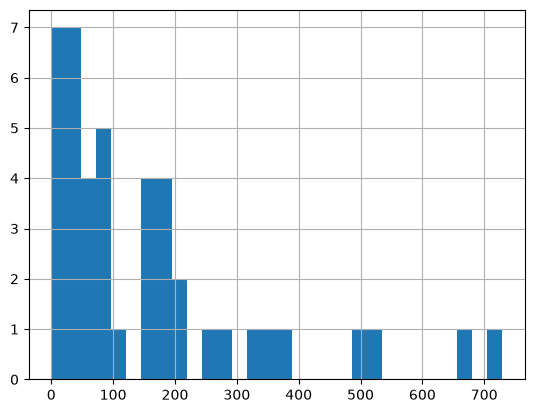

In [61]:
base_lima["Muertes Covid"].hist(bins=30)

In [62]:
PH_lima_postas

,Institución,Código Único,Nombre del establecimiento,Clasificación,Tipo,Departamento,Provincia,Distrito,UBIGEO,Dirección,...,Situación,Condición,Inspección,NORTE,ESTE,COTA,CAMAS,code1,code2,geometry
2725,MINSA,5824,SAN JOSE,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,LIMA,LIMA,ANCON,150102,ESQ. CALLE Nº 17 Y CALLE Nº 9 URB. DE INTERES ...,...,,EN FUNCIONAMIENTO,,-77.162575,-11.778237,12.0,NaN,19,1,POINT (-77.16258 -11.77824)
2728,MINSA,14727,PROFAM,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,LIMA,LIMA,SANTA ROSA,150139,"AV. SANTA ROSA, MANZANA O-2 / ASOCIACION DE VI...",...,,EN FUNCIONAMIENTO,,-77.159128,-11.817327,NaN,NaN,19,1,POINT (-77.15913 -11.81733)
2740,MINSA,16525,VILLAS DE ANCON,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,LIMA,LIMA,ANCON,150102,MZ X ASOCIACION PRO-VIVIENDA VILLAS DE ANCON,...,,EN FUNCIONAMIENTO,,-77.145966,-11.733970,0.0,NaN,19,1,POINT (-77.14597 -11.73397)
2762,MINSA,5825,VIRGEN DE LAS MERCEDES,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,LIMA,LIMA,SANTA ROSA,150139,ASOC. VIV. SANTA ROSA MZ. B LT. 09,...,,EN FUNCIONAMIENTO,,-77.131677,-11.815250,12.0,NaN,19,1,POINT (-77.13168 -11.81525)
2797,MINSA,5750,CERRO LA REGLA,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,LIMA,LIMA,SAN MARTIN DE PORRES,150135,"MZ B LT 11 - AAHH ESPERANZA, COMITÉ 2",...,,EN FUNCIONAMIENTO,,-77.115765,-11.989613,123.0,NaN,19,1,POINT (-77.11576 -11.98961)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,MINSA,5868,SEÑOR DE LOS MILAGROS,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,LIMA,LIMA,LURIGANCHO,150118,AVENIDA AV.PRECURSORES S/N AAHH NICOLAS DE PIE...,...,,EN FUNCIONAMIENTO,,-76.714793,-11.935857,911.0,NaN,19,1,POINT (-76.71479 -11.93586)
3516,MINSA,5870,PABLO PATRON,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,LIMA,LIMA,LURIGANCHO,150118,AAHH PABLO PATRON - CALLE 14 MZ. V LOTE 7 DIST...,...,,EN FUNCIONAMIENTO,,-76.686205,-11.930408,911.0,NaN,19,1,POINT (-76.6862 -11.93041)
3519,MINSA,5867,MARISCAL CASTILLA,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,LIMA,LIMA,LURIGANCHO,150118,CALLE SANTA ROSA MZ O S/N - AAHH MARISCAL CAST...,...,,EN FUNCIONAMIENTO,,-76.685491,-11.933911,911.0,NaN,19,1,POINT (-76.68549 -11.93391)
8125,MINSA,5940,HUASCATA,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,LIMA,LIMA,CHACLACAYO,150107,OTROS MZ N LOTE 05 AAHH CERRO VECINO HUASCATA-...,...,,EN FUNCIONAMIENTO,,NaN,NaN,NaN,NaN,19,1,POINT (NaN NaN)


<Axes: >

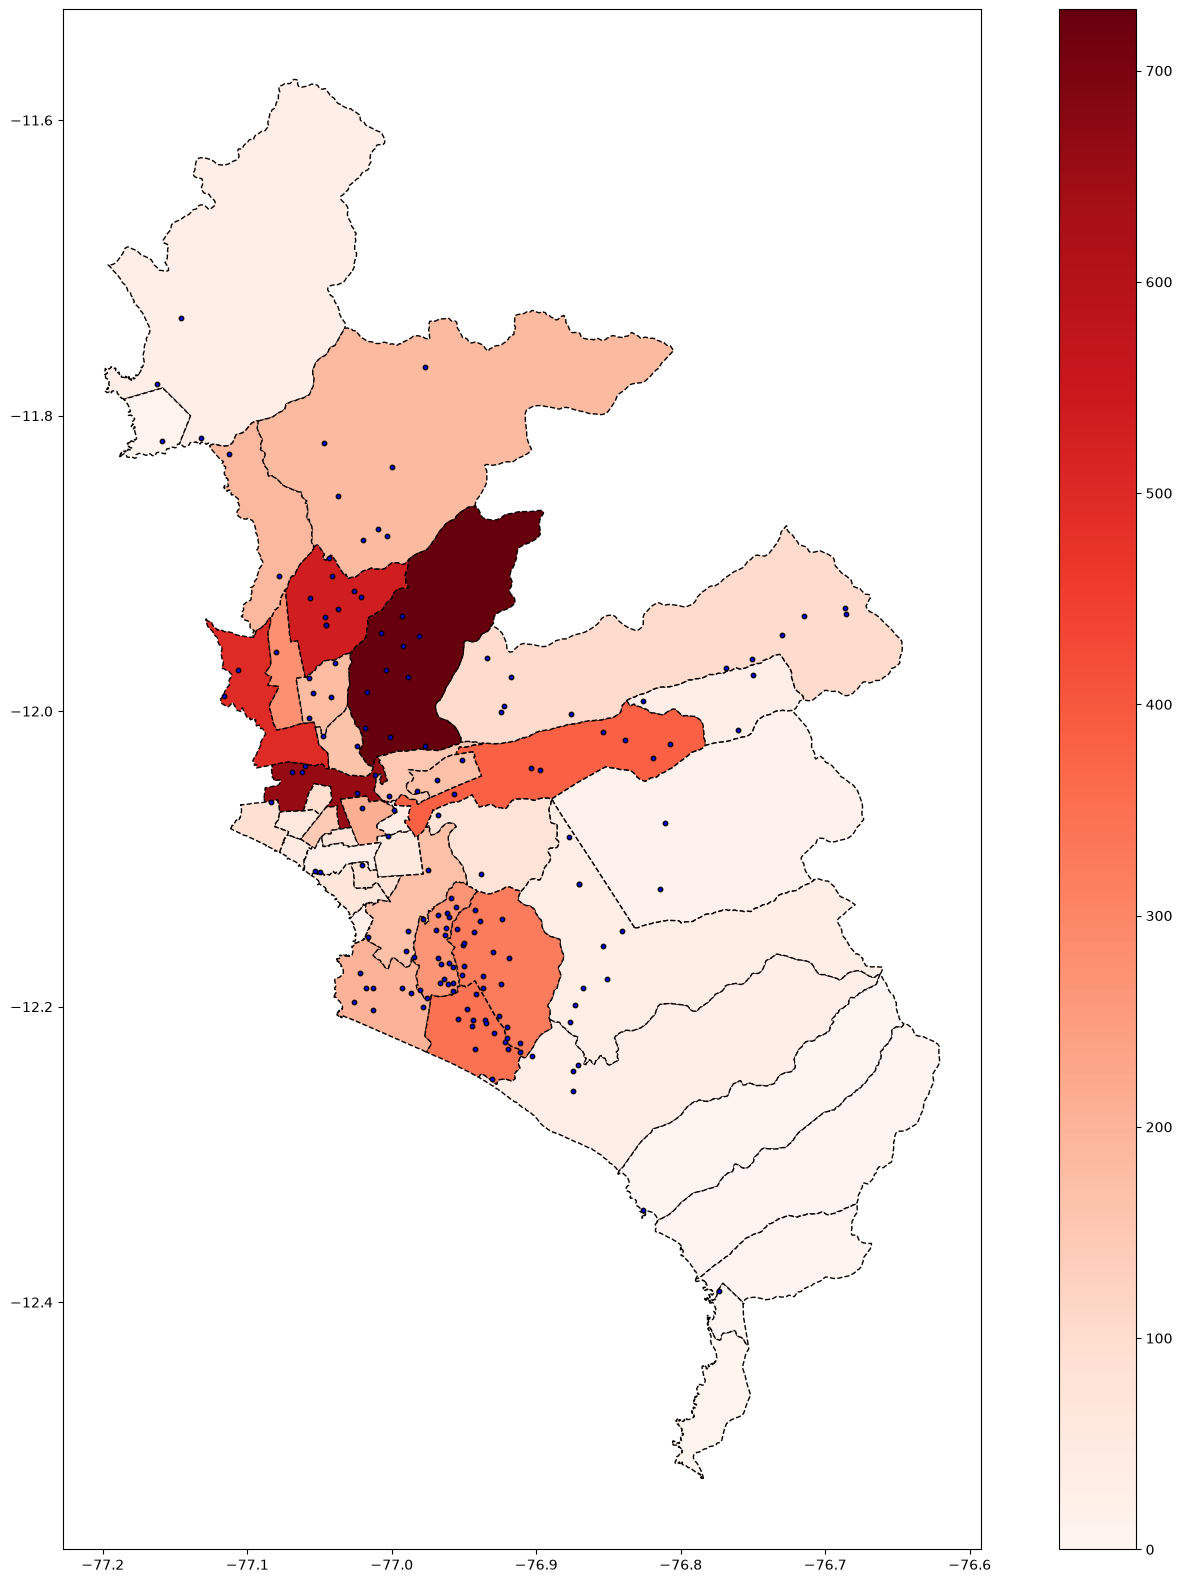

In [63]:
# Covid deaths and Postas médicas 

fig, ax = plt.subplots(figsize=(20, 20))

#Heatmap Lima and Covid infection

base_lima.plot( column='Muertes Covid', 
               cmap='Reds', 
               linestyle='--',
               edgecolor='black', 
               legend = True, 
               ax=ax )

# Plot in the shapefile (R style)
PH_lima_postas.plot(ax = ax, color = 'blue', markersize=10, edgecolor='black')

## Hospitales Públicos y Postas Médicas

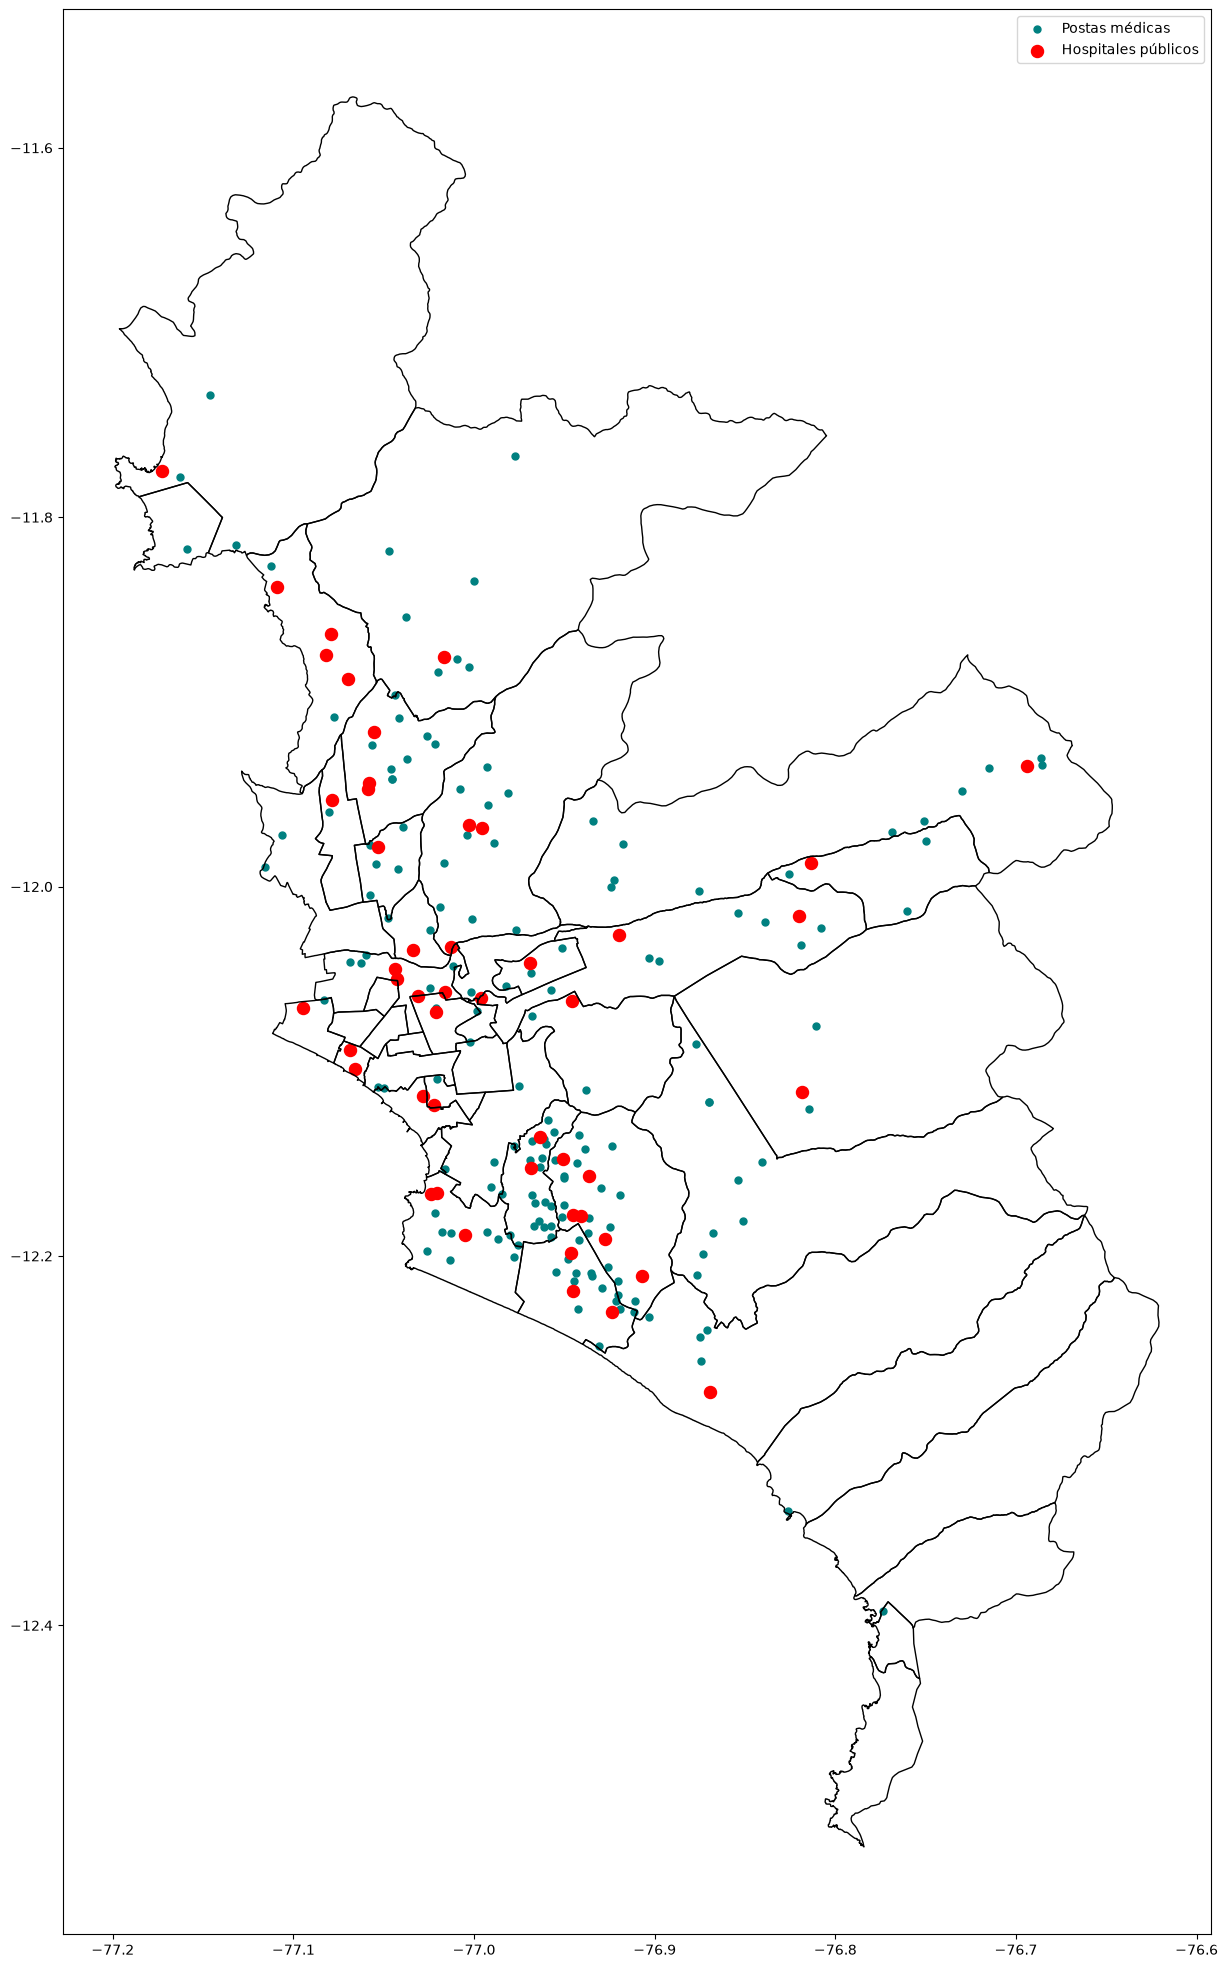

In [64]:
ax = base_lima.plot(figsize=(25, 25), color='none', edgecolor='black', zorder=3)

PH_lima_postas.plot(color='teal', label = "Postas médicas", markersize=25, ax=ax)
PH_lima_hospitales.plot(color='red', label = "Hospitales públicos", markersize=75, ax=ax)

plt.legend(loc='upper right')

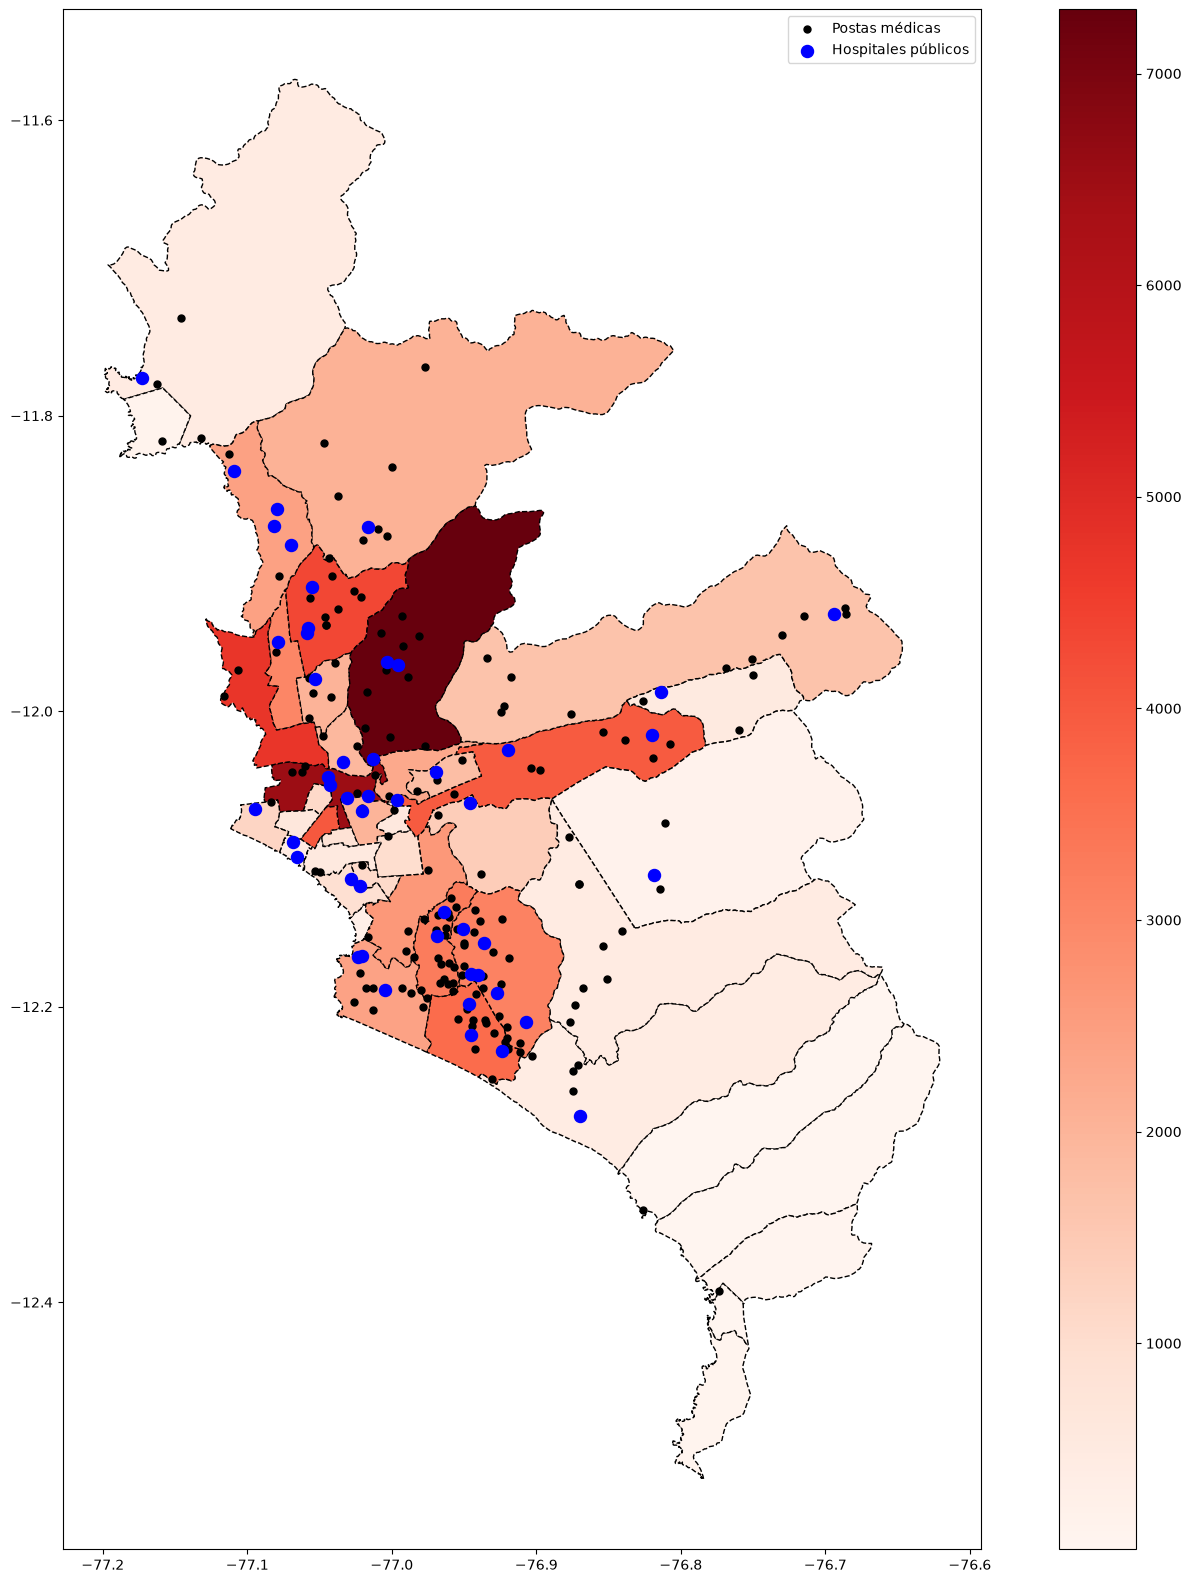

In [65]:
# Covid infection and Postas médicas 

fig, ax = plt.subplots(figsize=(20, 20))

#Heatmap Lima and Covid infection

base_lima.plot(column='Casos', cmap='Reds', linestyle='--',
                      edgecolor='black', 
                      legend = True, ax=ax)

PH_lima_postas.plot(color='black', label = "Postas médicas", markersize=25, ax=ax)
PH_lima_hospitales.plot(color='blue', label = "Hospitales públicos", markersize=75, ax=ax)

plt.legend(loc='upper right')

In [66]:
PH_lima_hospitales['CAMAS'].describe()

count     20.000000
mean     161.400000
std      204.603442
min        6.000000
25%       49.750000
50%       75.500000
75%      162.250000
max      662.000000
Name: CAMAS, dtype: float64

In [67]:
# drop raws with nan values 

PH_lima_hospitales = PH_lima_hospitales.dropna(subset=['CAMAS'])

In [68]:
#markersize

## Relative Size of Markers from panda series

In [69]:
PH_lima_hospitales["CAMAS"]

2832     49.0
2859    102.0
2887    590.0
2905    106.0
2943     49.0
2955    662.0
2988    231.0
2997     84.0
3040    594.0
3077    150.0
3093      6.0
3096     54.0
3161      6.0
3214     50.0
3230    199.0
3269    111.0
3363     51.0
3382     10.0
3508     67.0
7909     57.0
Name: CAMAS, dtype: float64

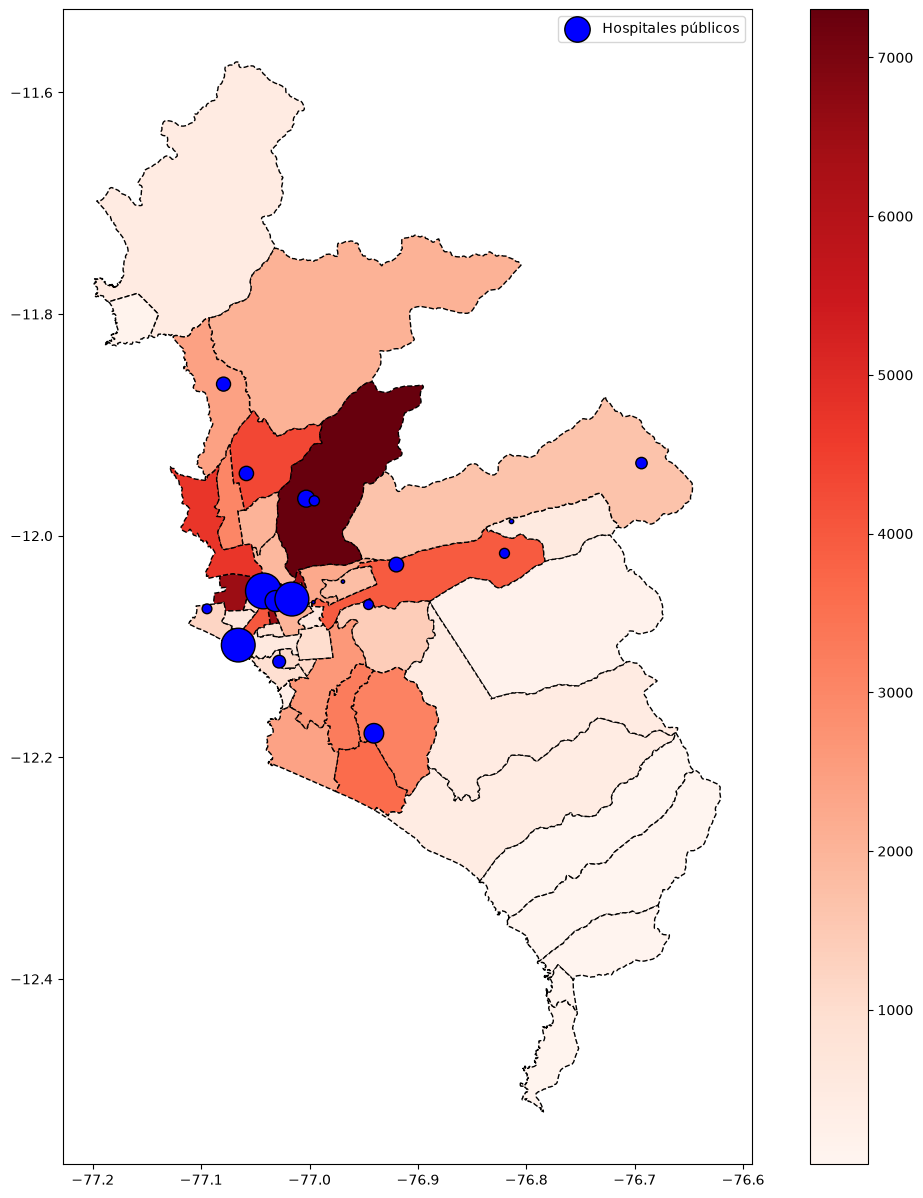

In [70]:
# Covid infection and Public Hospital by number of beds 

fig, ax = plt.subplots(figsize=(15, 15))

#define the size
markersize=PH_lima_hospitales['CAMAS']

#Heatmap Lima and Covid infection

base_lima.plot(column='Casos', cmap='Reds', linestyle='--',
                      edgecolor='black', 
                      legend = True, ax=ax)

PH_lima_hospitales.plot( ax=ax, color='blue', label = "Hospitales públicos", markersize = markersize,
                       edgecolor='black')
plt.legend(loc='upper right')

<Axes: >

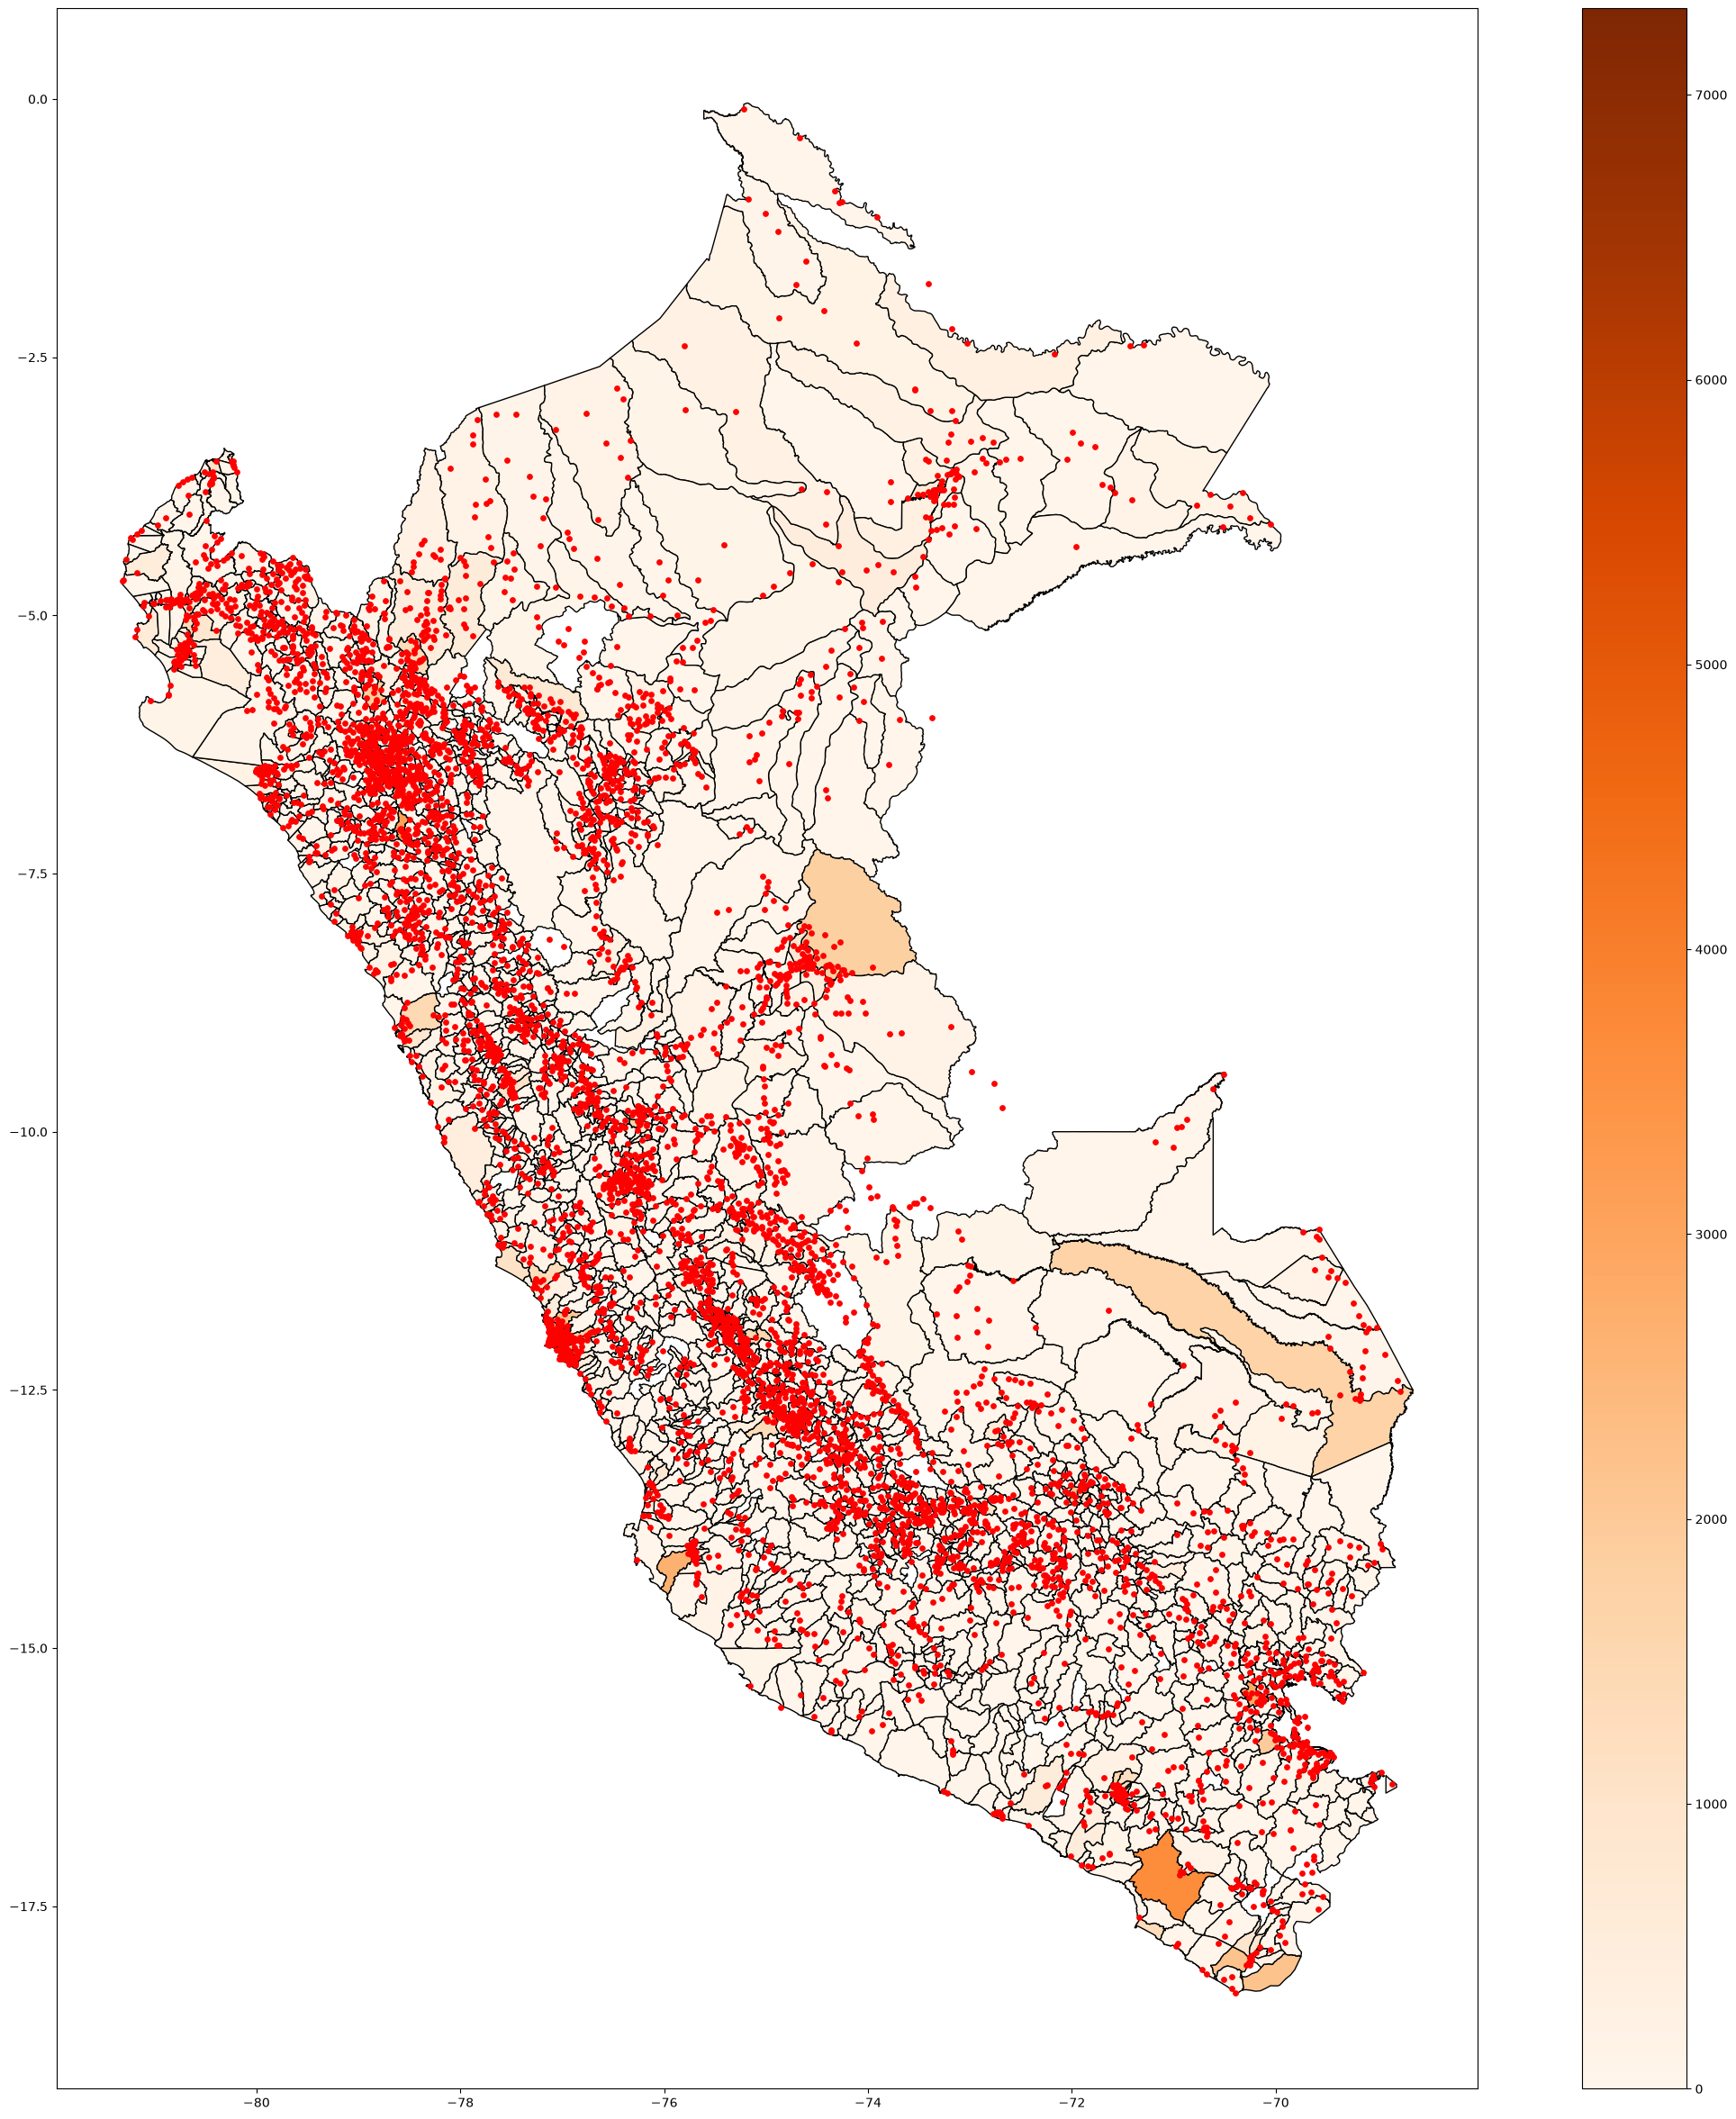

In [71]:
# Covid infection & postas médicas at the national level 

gf = base.plot(column='Casos', cmap='Oranges', 
          figsize=(30, 30),
          linestyle='-',
          edgecolor='black',
          legend = True)

Public_health1.plot(ax = gf, color = 'red', markersize=15)

## Select Districts

In [72]:
base_lima = base_lima.set_index("Distrito")

In [73]:
base_lima

,UBIGEO,Año,Mes,geometry,Departamento,Provincia,Casos,Muertes Covid,Muertes totales,centroid
Distrito,,,,,,,,,,
LIMA,150101,2020,8,"POLYGON ((-77.00474 -12.04166, -77.00296 -12.0...",LIMA,LIMA,6510.0,658.0,666.0,POINT (-77.04887 -12.05103)
ANCON,150102,2020,8,"POLYGON ((-77.06517 -11.57512, -77.06505 -11.5...",LIMA,LIMA,460.0,30.0,51.0,POINT (-77.0958 -11.70252)
ATE,150103,2020,8,"POLYGON ((-76.83508 -11.99627, -76.83467 -11.9...",LIMA,LIMA,3969.0,382.0,545.0,POINT (-76.87747 -12.03257)
BARRANCO,150104,2020,8,"POLYGON ((-77.01945 -12.1306, -77.01915 -12.13...",LIMA,LIMA,298.0,26.0,62.0,POINT (-77.02086 -12.14403)
BRE<d1>A,150105,2020,8,"POLYGON ((-77.04206 -12.05348, -77.04198 -12.0...",LIMA,LIMA,1129.0,95.0,180.0,POINT (-77.05059 -12.05916)
CARABAYLLO,150106,2020,8,"POLYGON ((-76.89995 -11.72979, -76.89921 -11.7...",LIMA,LIMA,2054.0,183.0,281.0,POINT (-76.97291 -11.80738)
CHACLACAYO,150107,2020,8,"POLYGON ((-76.72918 -11.96426, -76.72809 -11.9...",LIMA,LIMA,512.0,31.0,62.0,POINT (-76.76695 -11.99164)
CHORRILLOS,150108,2020,8,"POLYGON ((-77.00745 -12.16033, -77.00781 -12.1...",LIMA,LIMA,2400.0,203.0,333.0,POINT (-77.00589 -12.19265)
CIENEGUILLA,150109,2020,8,"POLYGON ((-76.72948 -11.99943, -76.72596 -11.9...",LIMA,LIMA,161.0,12.0,25.0,POINT (-76.77752 -12.07646)


In [74]:
# base_lima esta en EPSG:4326 (grados). Un buffer de 10000 ahi son 10000 GRADOS.
# Se proyecta a EPSG:24891 (metros, Peru) para que 10 km signifiquen 10 km.
base_lima_m = base_lima.to_crs(epsg=24891)
base_lima_m.buffer(10000)

Distrito
LIMA                       POLYGON ((584040.542 756988.702, 584095.225 75...
ANCON                      POLYGON ((572236.339 785811.554, 572194.105 78...
ATE                        POLYGON ((595506.468 748487.735, 595291.586 74...
BARRANCO                   POLYGON ((590658.886 742005.306, 590608.833 74...
BRE<d1>A                   POLYGON ((587495.116 757571.137, 587527.001 75...
CARABAYLLO                 POLYGON ((583929.371 780380.729, 583794.005 78...
CHACLACAYO                 POLYGON ((620054.791 751422.436, 619610.363 75...
CHORRILLOS                 POLYGON ((589008.425 740958.431, 588997.877 74...
CIENEGUILLA                POLYGON ((612625.105 740406.935, 610097.415 74...
COMAS                      POLYGON ((585763.964 768689.382, 585758.273 76...
EL AGUSTINO                POLYGON ((592363.459 757393.754, 592367.059 75...
INDEPENDENCIA              POLYGON ((586804.326 760232.667, 586745.204 76...
JESUS MARIA                POLYGON ((589404.512 758808.319, 589523.

In [75]:
# Buffer de 10 km y centroides, calculados en metros y devueltos a EPSG:4326
base_lima["buffered"] = base_lima_m.buffer(10000).to_crs(epsg=4326)
base_lima["centroid"] = base_lima_m.centroid.to_crs(epsg=4326)

<Axes: >

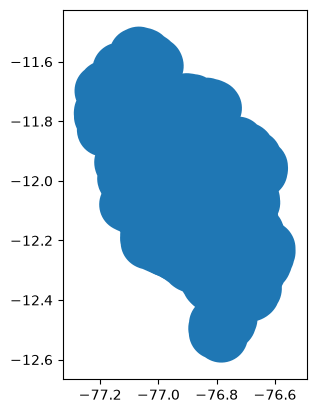

In [76]:
base_lima.buffered.plot()

<Axes: >

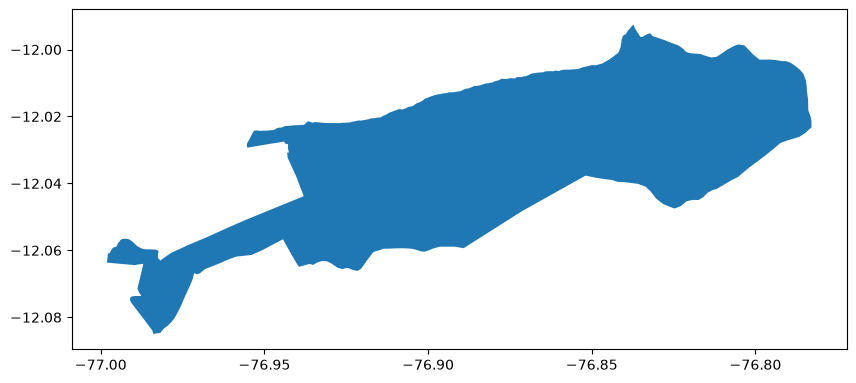

In [77]:
# Filtrado por UBIGEO (nombre distinto para no pisar el poligono ATE de la celda siguiente)
ate_gdf = base_lima[base_lima.UBIGEO == 150103]
ate_gdf.plot(figsize=(10, 10))

<Axes: >

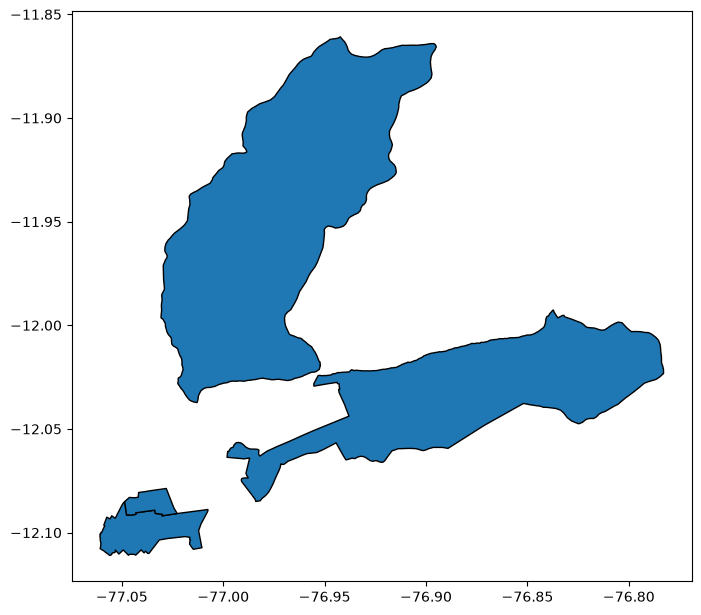

In [78]:
# Distritos seleccionados: version en grados (para graficar)
ATE = base_lima.loc["ATE", "geometry"]
SJL = base_lima.loc["SAN JUAN DE LURIGANCHO", "geometry"]
SI  = base_lima.loc["SAN ISIDRO", "geometry"]
LC  = base_lima.loc["LINCE", "geometry"]

# ... y version proyectada en metros (para distancias)
ATE_m = base_lima_m.loc["ATE", "geometry"]
SJL_m = base_lima_m.loc["SAN JUAN DE LURIGANCHO", "geometry"]
SI_m  = base_lima_m.loc["SAN ISIDRO", "geometry"]
LC_m  = base_lima_m.loc["LINCE", "geometry"]

gpd.GeoSeries([ATE, SJL, SI, LC], crs=base_lima.crs).plot(
    figsize=(8, 8), linestyle='-', edgecolor='black')

## Limits - Boarders

In [79]:
# Logic operations:

# Lince and San Isidro share limits 

LC.touches(SI)

True

In [80]:
LC.touches(ATE)

False

In [81]:
# Distancia ATE - SAN ISIDRO, en kilometros (sobre la version proyectada)
ATE_m.distance(SI_m) / 1000

2.350239164948182

<Axes: >

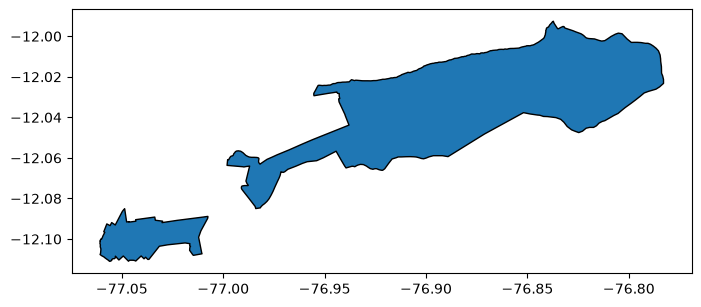

In [82]:
gpd.GeoSeries([ATE, SI]).plot(figsize=(8, 8),linestyle='-',
                                    edgecolor='black')

In [83]:
# Distancia ATE - LINCE, en kilometros
ATE_m.distance(LC_m) / 1000

3.6691332053513537

In [84]:
# Add line that cross Lince and ATE

ate_point = base_lima['centroid']['ATE']
lc_point = base_lima['centroid']['LINCE']
sb_point = base_lima['centroid']['SAN BORJA']
lr_point = base_lima['centroid']['LURIN']
ac_point = base_lima['centroid']['ANCON']


<Axes: >

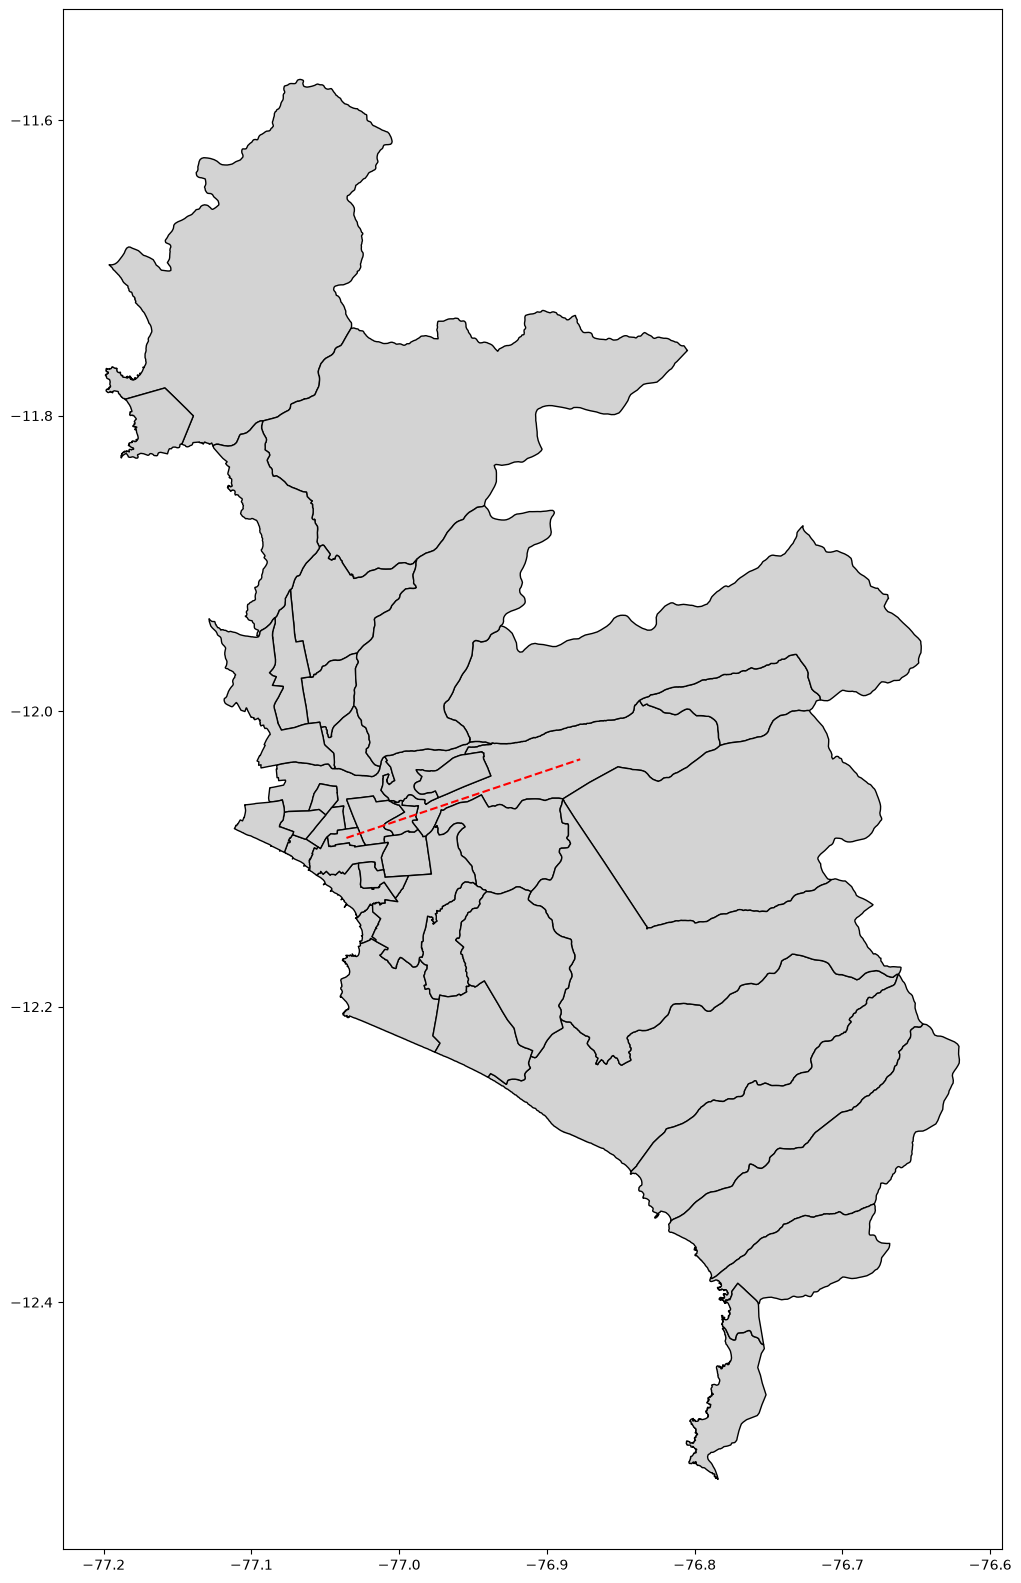

In [85]:
# Add line that cross Lince and ATE

ate_lince = LineString(zip((ate_point.x , lc_point.x ), (ate_point.y, lc_point.y)))

fig, ax = plt.subplots(figsize=(20,20))
base_lima.plot(color='lightgray', ax=ax, linestyle='-',
                                    edgecolor='black')

gpd.GeoSeries([ate_lince]).plot(color='red', linestyle='--', ax = ax)

In [86]:
# Area en km2 (calculada en la proyeccion metrica, no en grados)
base_lima['area_km2'] = base_lima_m.area / 1e6
base_lima[['UBIGEO', 'area_km2']].sort_values('area_km2', ascending=False).head(10)

,UBIGEO,area_km2
Distrito,,
CARABAYLLO,150106,313.175763
ANCON,150102,311.513517
LURIGANCHO,150118,245.960878
CIENEGUILLA,150109,225.789410
LURIN,150119,188.298956
PACHACAMAC,150123,186.554673
SAN JUAN DE LURIGANCHO,150132,140.874118
PUNTA NEGRA,150127,130.151771
PUNTA HERMOSA,150126,122.402962


In [87]:
# Distancia de San Juan de Lurigancho al resto de distritos, en km

SJL_point_m = base_lima_m.centroid.loc["SAN JUAN DE LURIGANCHO"]   # metros, para distancias
SJL_point   = base_lima['centroid']["SAN JUAN DE LURIGANCHO"]      # grados, para dibujar lineas

base_lima['distance_km'] = base_lima_m.centroid.distance(SJL_point_m) / 1000

In [88]:
base_lima['distance_km'].sort_values(ascending=False)

Distrito
PUCUSANA                   61.442353
SANTA MARIA DEL MAR        55.888044
SAN BARTOLO                54.122816
PUNTA NEGRA                48.866264
PUNTA HERMOSA              43.594370
LURIN                      36.960339
VILLA EL SALVADOR          30.421228
ANCON                      30.193037
PACHACAMAC                 29.569310
CHORRILLOS                 27.590779
SANTA ROSA                 26.111250
CIENEGUILLA                25.630660
VILLA MARIA DEL TRIUNFO    25.520254
SAN JUAN DE MIRAFLORES     23.486600
CHACLACAYO                 22.883941
BARRANCO                   22.598403
MIRAFLORES                 20.373115
SANTIAGO DE SURCO          20.108335
SAN MIGUEL                 19.399160
MAGDALENA DEL MAR          19.399104
SURQUILLO                  19.101627
LURIGANCHO                 18.621949
SAN ISIDRO                 18.385947
PUEBLO LIBRE               17.618349
LINCE                      17.002230
SAN BORJA                  16.995137
JESUS MARIA                16

Text(0, 0.5, 'Distancia a SJL (km)')

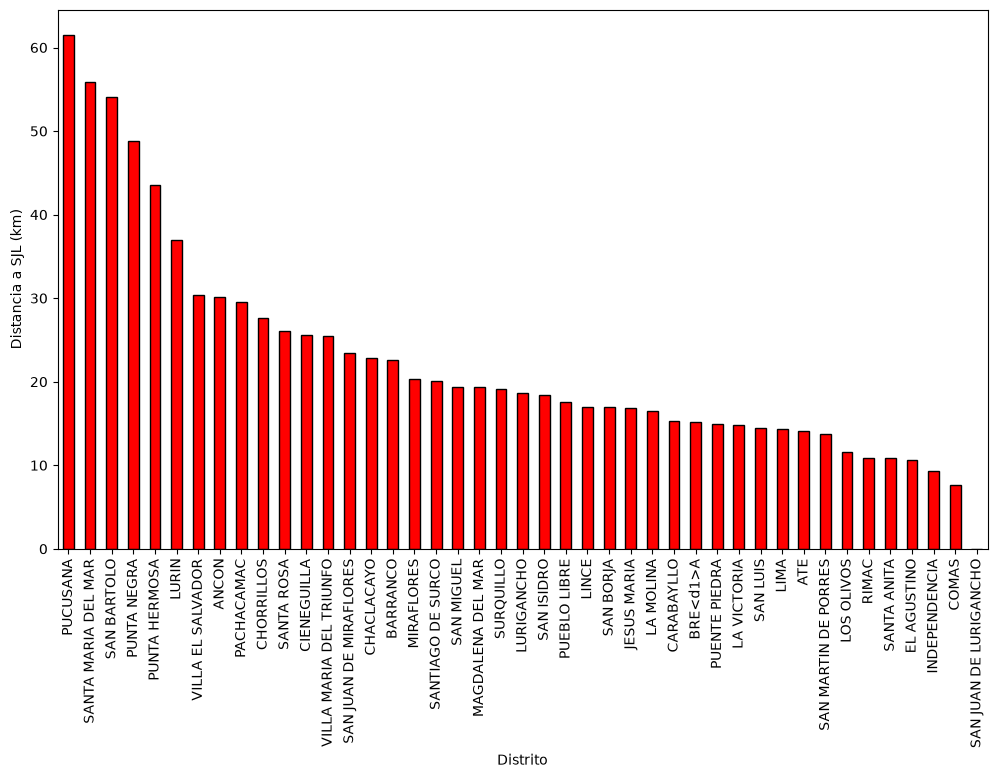

In [89]:
ax = base_lima['distance_km'].sort_values(ascending=False).plot.bar(
    figsize=(12, 7), color='red', edgecolor='black')
ax.set_ylabel('Distancia a SJL (km)')

In [90]:
# En Shapely 2.x el atributo es .geom_type (.type quedo deprecado)
ate_point.geom_type

'Point'

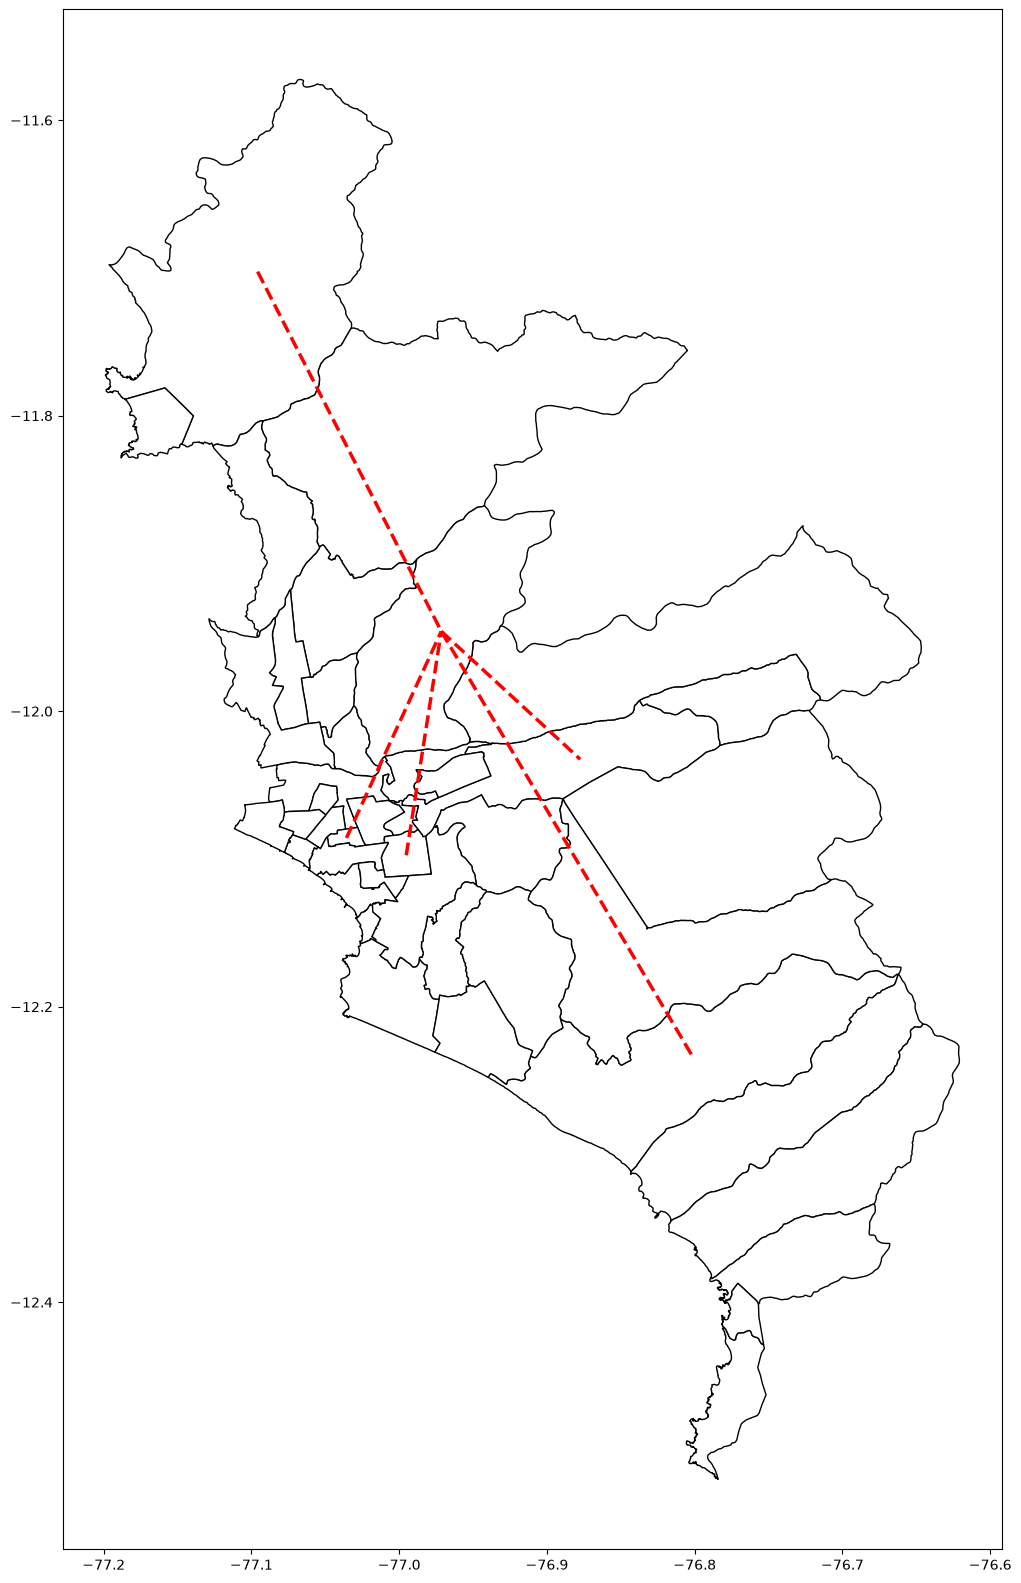

In [91]:
# SJL and other districs 

d1 = LineString(zip((SJL_point.x , lc_point.x ), (SJL_point.y, lc_point.y)))
d2 = LineString(zip((SJL_point.x , ate_point.x ), (SJL_point.y, ate_point.y)))
d3 = LineString(zip((SJL_point.x , sb_point.x ), (SJL_point.y, sb_point.y)))
d4 = LineString(zip((SJL_point.x , lr_point.x ), (SJL_point.y, lr_point.y)))
d5 = LineString(zip((SJL_point.x , ac_point.x ), (SJL_point.y, ac_point.y)))

fig, ax = plt.subplots(figsize=(20,20))
base_lima.plot(color='white', ax=ax, linestyle='-',
                                    edgecolor='black')

for i in range(1,6):
    gpd.GeoSeries(globals()[f'd{i}']).plot(color='red', linestyle='--', ax = ax, linewidth = 2.5)



## ArcGis Operations in Geopandas

In [92]:
# _data/shape_file/ no existe: el shapefile distrital vive en _data/Folium/
dist_shp = gpd.read_file(r'../../_data/Folium/DISTRITOS.shp')

### Get Centroids
Get the centroids of each geometry (district).

In [93]:
dist_shp.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [94]:
dist_shp.to_crs(24891).centroid.to_crs( 4326 )

0        POINT (-75.46643 -9.63426)
1         POINT (-74.8663 -9.00133)
2        POINT (-75.04801 -8.82493)
3        POINT (-75.27987 -8.95039)
4        POINT (-75.04902 -8.64129)
                   ...             
1868     POINT (-76.03798 -9.20808)
1869     POINT (-76.00134 -9.08221)
1870     POINT (-75.98295 -8.98489)
1871    POINT (-70.12642 -15.40623)
1872    POINT (-77.44521 -11.00357)
Length: 1873, dtype: geometry

In [95]:
dist_shp.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

We get warnings since we need to reproject this shapefile object to a CRS in meters. This CRS should be a plane area to the specific zone of the shapefile ([more info](https://stackoverflow.com/questions/63004400/getting-a-userwarning-when-calculating-centroid-of-a-geoseries)). In the case of Peru, we use 24891 ([more info](https://epsg.io/24891)).



In [96]:
projected_dist_shp = dist_shp.to_crs( epsg = 24891 )

projected_dist_shp[ 'centroids'] = projected_dist_shp.centroid

Then, we reproject again the centroids to the original CRS.

In [97]:
dist_shp[ 'Centroid_Latitude' ] = projected_dist_shp[ 'centroids' ].to_crs( epsg = 4326 ).y
dist_shp[ 'Centroid_Longitude' ] = projected_dist_shp[ 'centroids' ].to_crs( epsg = 4326 ).x

## Intersection

In [98]:
# Backslash de Windows + ruta a un nivel: ambos rotos en macOS/Linux
health_centers = pd.read_csv(r"../../_data/salud_places_peru.csv", encoding='utf-8-sig')

In [99]:
ht1 = health_centers[ health_centers.latitud != 0 ]

In [100]:
# Make ht1 a geopandas
ht1_geo = gpd.GeoDataFrame( ht1 , 
                           geometry= gpd.points_from_xy( 
                                      ht1.longitud, 
                                      ht1.latitud))

Check CRS

We found that geolocation is recognized by google maps. We set the CRS that correspond to google maps.

In [101]:
ht1_geo_crs = ht1_geo.set_crs( epsg = 4326 )

Find Ubigeo for each point

In [102]:
# Just take 10% of observations
ht2_geo = ht1_geo_crs.sample( frac = 0.10 )

In [103]:
# Intersect with maps
intersected_ht = gpd.overlay( ht2_geo , maps , how = 'intersection' )

In [104]:
ht2_geo.columns

Index(['id_eess', 'codigo_renaes', 'categoria', 'nombre', 'diresa', 'red',
       'direccion', 'longitud', 'latitud', 'id_ubigeo', 'geometry'],
      dtype='str')

In [105]:
intersected_ht

,id_eess,codigo_renaes,categoria,nombre,diresa,red,direccion,longitud,latitud,id_ubigeo,UBIGEO,geometry
0,5500,6467,I-3,TRES UNIDOS,SAN MARTIN,PICOTA,JIRÓN JR. UCAYALI S/N CP TRES UNIDOS S/N JR. U...,-76.234398,-6.802077,1789,220710,POINT (-76.2344 -6.80208)
1,21284,20140,I-1,CONSULTORIO ODONTOLOGICO RAFAEL,SAN MARTIN,NO PERTENECE A NINGUNA RED,JIRÓN JR. SERAFIN FILOMENO Nº 592 DISTRITO MOY...,-76.974241,-6.032805,1741,220101,POINT (-76.97424 -6.0328)
2,13588,26576,I-2,MARIA DE LOS ANGELES GUZMAN DIAZ,PIURA,NO PERTENECE A NINGUNA RED,AVENIDA LOS COCOS NÚMERO 111 PISO 2 DEPARTAMEN...,-80.631839,-5.194903,1566,200101,POINT (-80.63184 -5.1949)
3,23445,11200,I-1,CCARAPA,HUANCAVELICA,ANGARAES,AVENIDA AV. VALENZUELA S/N NÚMERO S/N DISTRITO...,-74.626492,-12.966017,842,90307,POINT (-74.62649 -12.96602)
4,27239,3975,I-1,LIRCAYCCASA,HUANCAVELICA,ANGARAES,PLAZA PLAZA PRINCIPAL S/N S/N PLAZA PRINCIPAL ...,-74.579420,-12.977302,841,90306,POINT (-74.57942 -12.9773)
...,...,...,...,...,...,...,...,...,...,...,...,...
1539,18971,7433,I-1,POTRERO GRANDE,CAJAMARCA,SAN IGNACIO,OTROS CASERIO POTRERO GRANDE DISTRITO SAN JOSE...,-78.898131,-4.946301,653,60906,POINT (-78.89813 -4.9463)
1540,24078,24064,SD,AISPED PATAY RONDOS,HUANUCO,DOS DE MAYO,OTROS CENTRO POBLADO PATAY RONDOS. SN MARIAS D...,-76.710037,-9.604511,932,100316,POINT (-76.71004 -9.60451)
1541,8783,4601,I-1,LA MASMA,CAJAMARCA,CAJAMARCA,OTROS COMUNIDAD DE LA MASMA DISTRITO NAMORA PR...,-78.239428,-7.167394,573,60111,POINT (-78.23943 -7.16739)
1542,981,18951,SD,CENTRO ESPECIALIZADO DE CONTROL DE CRECIMIENTO...,CAJAMARCA,NO PERTENECE A NINGUNA RED,CALLE CALLE LOS ROSALES N° 132 - URB LAS FLORE...,-78.803298,-5.705536,636,60801,POINT (-78.8033 -5.70554)


## Aggregation

We have shapefiles at district levels. It is possible to aggregate districts at Department or Province level.

<Axes: >

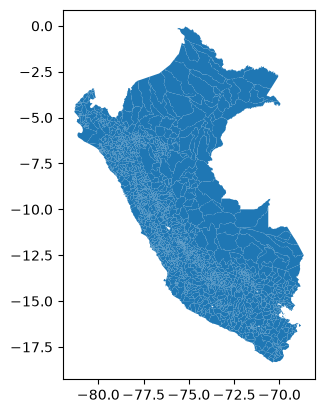

In [106]:
dist_shp.plot()

In [107]:
prov_shp = dist_shp.dissolve( by = 'IDPROV' )

<Axes: >

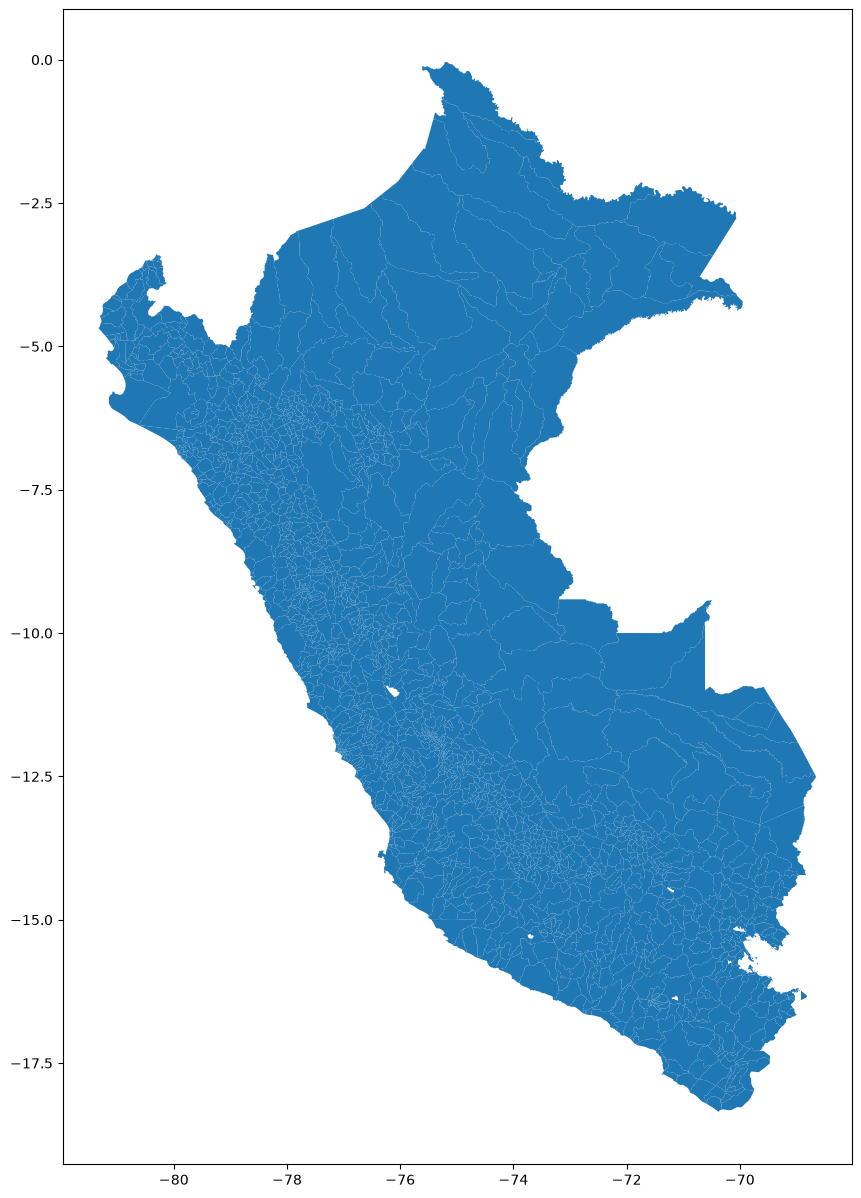

In [108]:
fig, ax = plt.subplots( figsize = ( 12, 15 ) )
dist_shp.plot( ax = ax )

<Axes: >

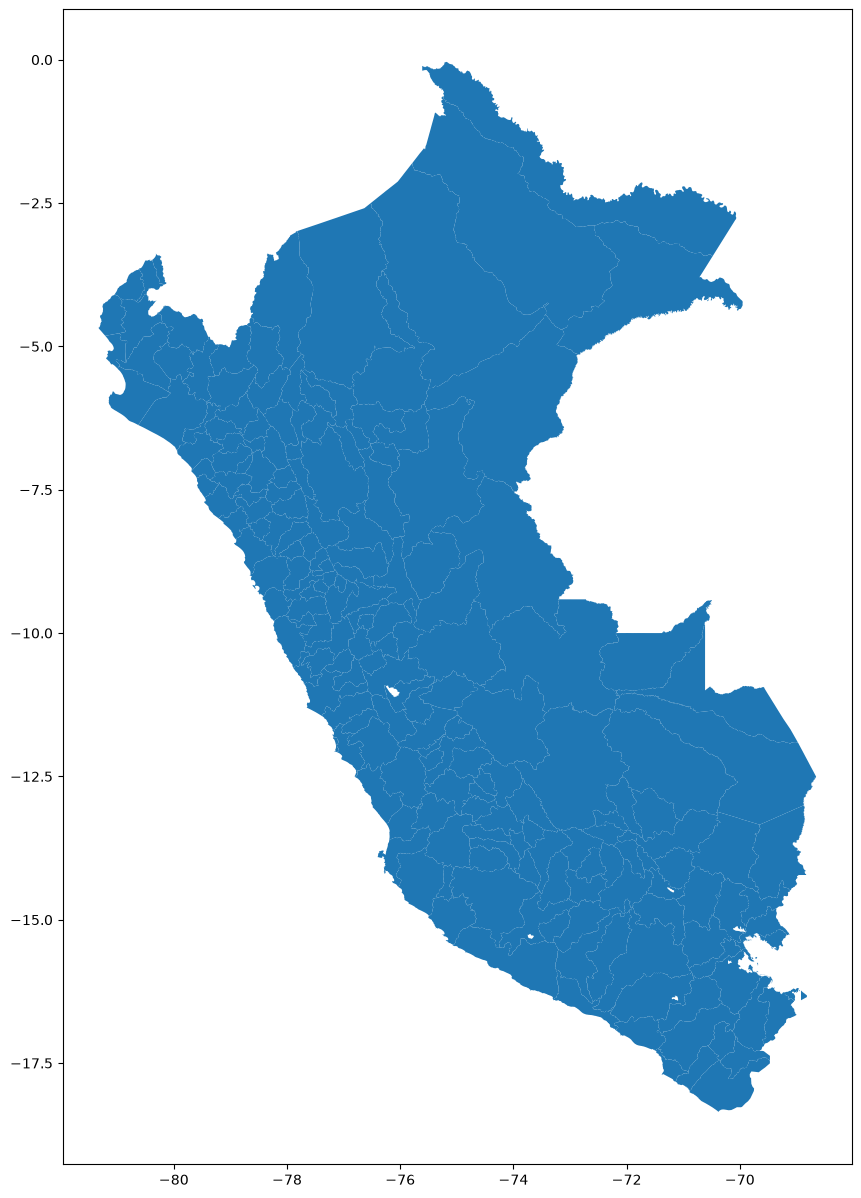

In [109]:
fig, ax = plt.subplots( figsize = ( 12, 15 ) )
prov_shp.plot( ax = ax )

In [110]:
dpt_shp = dist_shp.dissolve( by = 'IDDPTO' )

<Axes: >

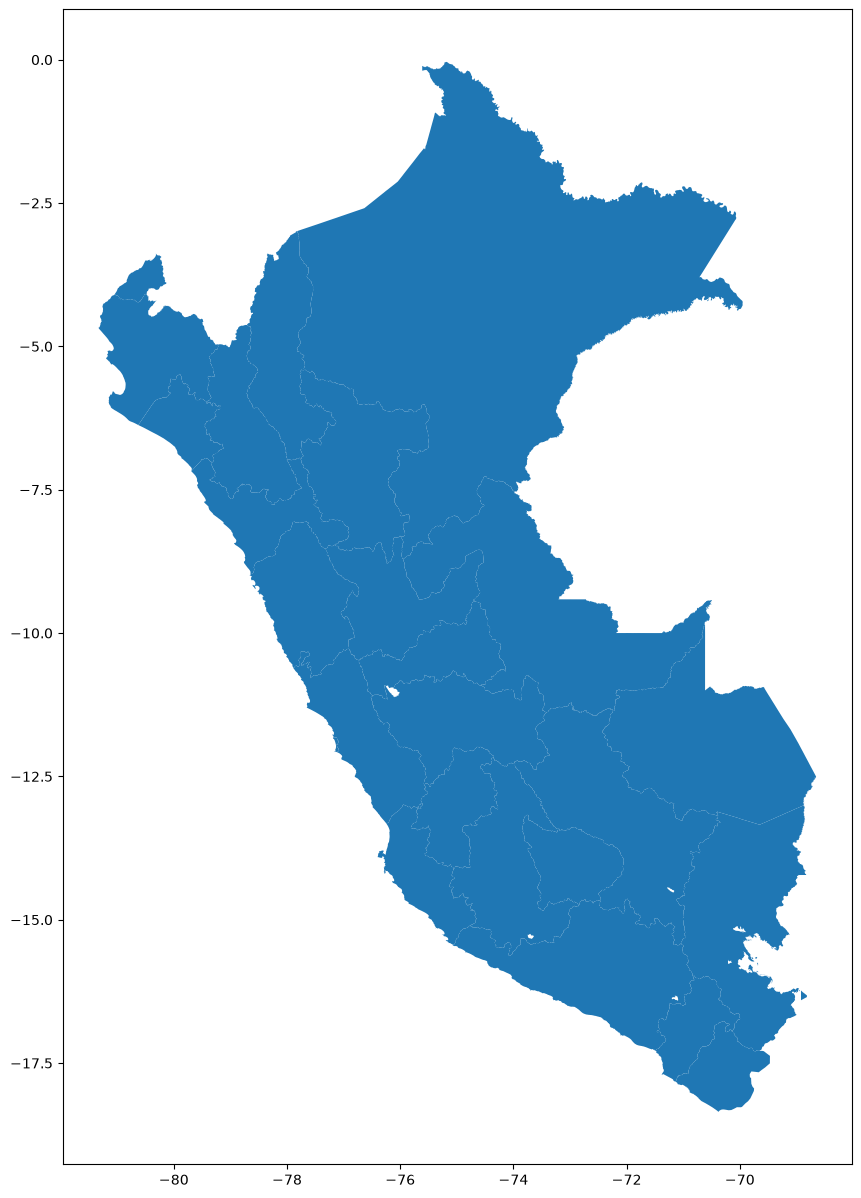

In [111]:
fig, ax = plt.subplots( figsize = ( 12, 15 ) )
dpt_shp.plot( ax = ax )

<Axes: >

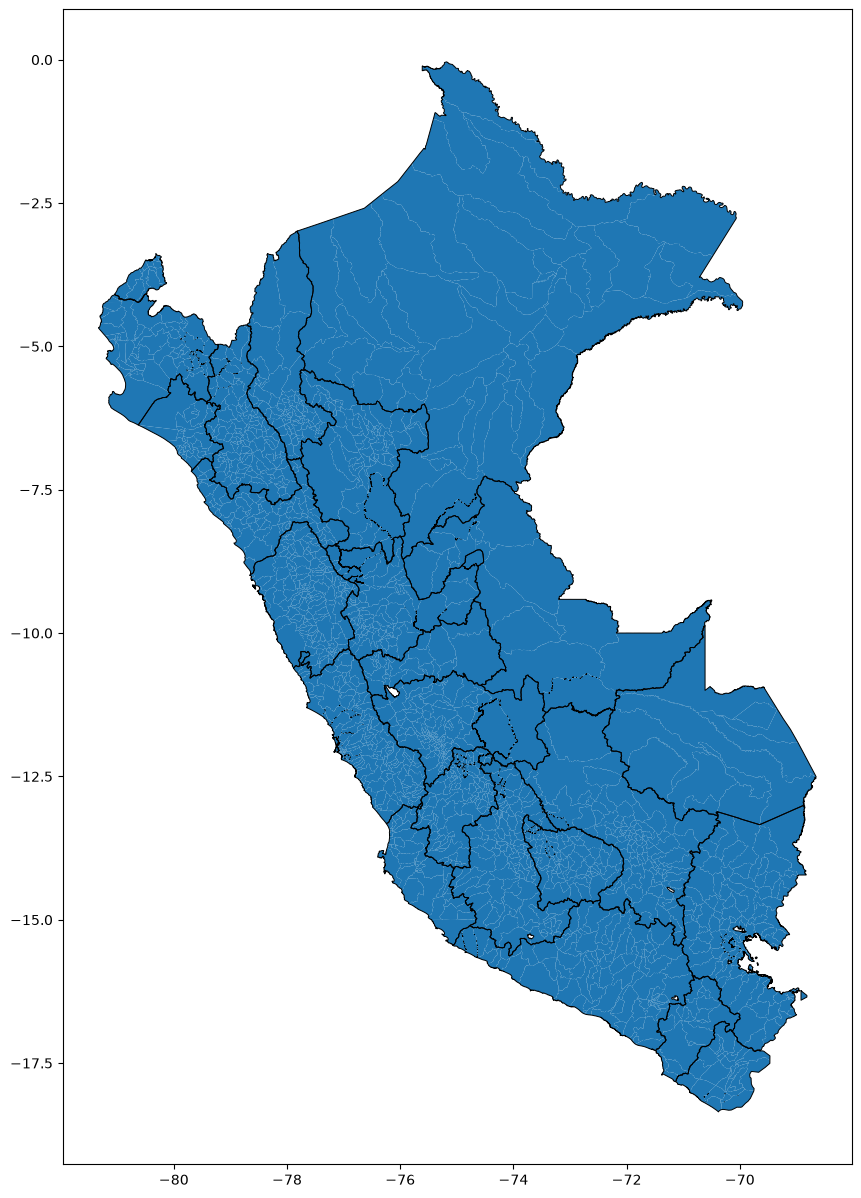

In [112]:
fig, ax = plt.subplots( figsize = ( 12, 15 ) )
dist_shp.plot( ax = ax )
dpt_shp.plot( ax = ax, facecolor="none",  edgecolor='black', lw=0.7 )

## Checking CRS

In [113]:
# Frontera de Suiza
ch_borders = gpd.read_file(r'../../_data/eu_maps/CHE_adm0.shp')

# Frontera de Alemania
de_borders = gpd.read_file(r'../../_data/eu_maps/gadm36_DEU_0.shp')

# Lagos suizos
ch_lakes = gpd.GeoDataFrame.from_file(r'../../_data/eu_maps/g2s15.shp')

# Municipios alemanes
Geo_muni = gpd.read_file(r"../../_data/eu_maps/VG250_GEM.shp")

Plots with different CRS

(np.float64(-46058.36469219931),
 np.float64(967356.691928138),
 np.float64(-305024.0777151486),
 np.float64(6406513.607306512))

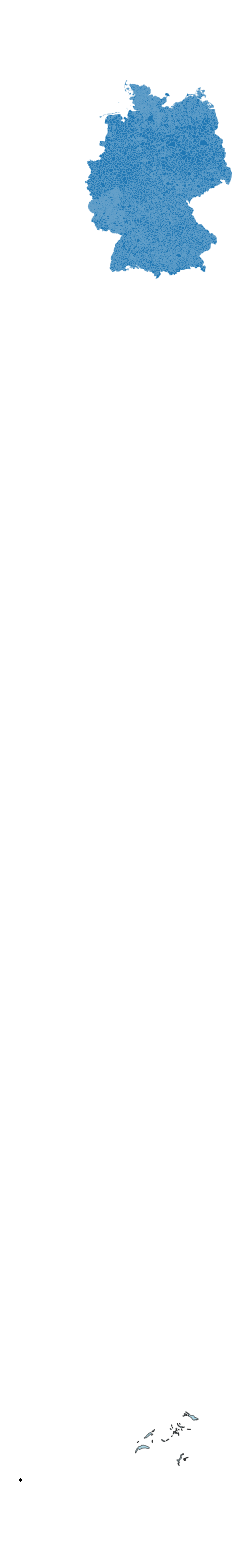

In [114]:

fig = plt.figure(figsize=(40, 20), dpi=100)
ax = fig.add_subplot(111, frame_on = False )

# German Plot
Geo_muni.plot( ax = ax )

# switzerland borders
ch_borders.geometry.boundary.plot(color = 'black', ax=ax, edgecolor='0.2', linewidth=1.5) 

# # Swiss lakes
ch_lakes.plot(color='lightblue' , ax=ax, edgecolor='0.2', linewidth=0.4, legend=True)

ax.axis('off')

# # define coordinates for the plot area
# ax.set_xlim(455869.5728, 927076.5648)
# #ax.set_ylim( auto = True)
# ax.set_ylim(60443.1884, 529941.7864)

# Save in pdf
# plt.savefig('maps/inventors_BW_bar_legend.pdf')


Check CRS

In [115]:
shp_files = [ ch_borders, de_borders, ch_lakes, Geo_muni ]

In [116]:
for shp in shp_files:
    print( shp.crs )
    
#cada informacion esta por su CRS, debe cambiarse

EPSG:4326
EPSG:4326
EPSG:21781
EPSG:25832


Reproject CRS

In [117]:
Geo_muni_crs = Geo_muni.to_crs( 21781 )

In [118]:
ch_borders_crs = ch_borders.to_crs( 21781 )

(np.float64(453126.0049465788),
 np.float64(1163640.4776774019),
 np.float64(11798.918320549674),
 np.float64(1157415.473468454))

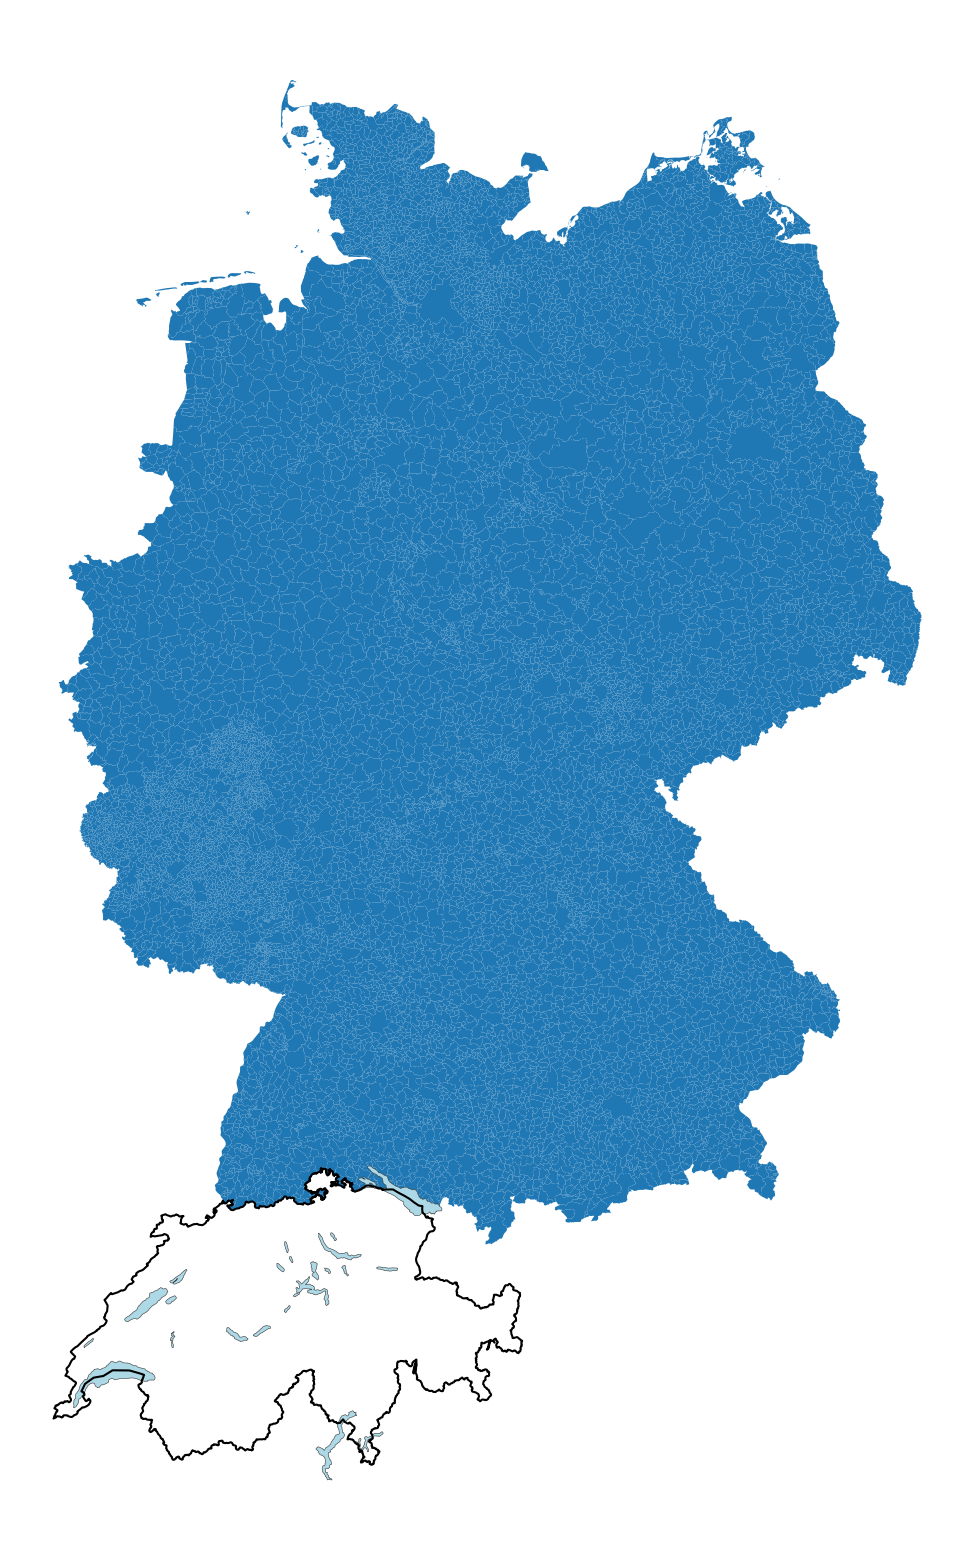

In [119]:

fig = plt.figure(figsize=(40, 20), dpi=100)
ax = fig.add_subplot(111, frame_on = False )

# German Plot
Geo_muni_crs.plot( ax = ax )

# switzerland borders
ch_borders_crs.geometry.boundary.plot(color = 'black', ax=ax, edgecolor='0.2', linewidth=1.5) 

# # Swiss lakes
ch_lakes.plot(color='lightblue' , ax=ax, edgecolor='0.2', linewidth=0.4, legend=True)

ax.axis('off')

# # define coordinates for the plot area
# ax.set_xlim(455869.5728, 927076.5648)
#ax.set_ylim( auto = True)
# ax.set_ylim(60443.1884, 529941.7864)

# Save in pdf
# plt.savefig('maps/inventors_BW_bar_legend.pdf')


## References:


### Geopandas
https://geopandas.org/en/stable/docs/user_guide/set_operations.html

https://geopandas.org/en/stable/docs/user_guide/aggregation_with_dissolve.html

https://geopandas.org/en/stable/docs/user_guide/data_structures.html

https://www.kaggle.com/imdevskp/geopandas

### Coordinate Reference System

https://geopandas.org/en/stable/docs/user_guide/projections.html

#### Types of projections

https://spatialreference.org/

#### Universal Transverse Mercator (UTM)

https://manifold.net/doc/mfd9/universal_transverse_mercator_projection.htm

